**Autor: David Díaz Paz y Puente**  
**Universidad de Monterrey** — SC3314 Inteligencia Artificial  
**Dr. Antonio Martínez Torteya**

# Proyecto Final – Unidad 3: Aprendizaje No Supervisado en Datos de Expresión Génica

---

## 1. Planteamiento del problema y contexto de los datos

### Contexto clínico

El **sarcoma uterino** (Uterine Corpus Sarcoma, UCS) es un grupo de tumores malignos poco frecuentes que se originan en el tejido mesenquimal del cuerpo uterino. Representan aproximadamente el 3–9% de todos los cánceres uterinos, pero son responsables de una proporción desproporcionadamente alta de muertes por cáncer ginecológico debido a su comportamiento agresivo y su tendencia a presentarse en estados avanzados. Desde el punto de vista histológico, el UCS engloba varios subtipos —carcinosarcoma, leiomiosarcoma, sarcoma del estroma endometrial y adenosarcoma— que difieren en su biología molecular, respuesta al tratamiento y pronóstico.

### Motivación del análisis

Dado que los subtipos histológicos de UCS exhiben perfiles moleculares distintos, el análisis de expresión génica a escala genómica ofrece la posibilidad de identificar subgrupos de pacientes con características moleculares compartidas que no son evidentes mediante la clasificación clínico-patológica convencional. Identificar estos subgrupos puede tener implicaciones directas en el diseño de tratamientos dirigidos y en la estratificación pronóstica.

### Objetivo del análisis

El objetivo de este trabajo es aplicar técnicas de aprendizaje no supervisado: reducción de dimensionalidad mediante PCA y algoritmos de clustering (K-means y clustering jerárquico), sobre datos de expresión génica de pacientes con UCS del TCGA, con el fin de:

1. Identificar subgrupos moleculares reproducibles en los datos.
2. Caracterizar cada subgrupo mediante los genes con mayor diferencia de expresión entre clusters.
3. Explorar si los subgrupos moleculares se asocian con variables clínicas como género, raza, edad o supervivencia.

### Origen de los datos

Los datos provienen de **The Cancer Genome Atlas (TCGA)**, accedidos a través de la plataforma **UCSC Xena** (https://xenabrowser.net/), cohorte **GDC TCGA Uterine Corpus Sarcoma (UCS)**. Se utilizaron tres archivos:

| Archivo | Descripción |
|---|---|
| `TCGA-UCS.star_tpm.tsv.gz` | Expresión génica (STAR–TPM); 60,660 genes × 57 muestras |
| `TCGA-UCS.clinical.tsv.gz` | Variables clínicas (fenotipo) de los 57 pacientes |
| `TCGA-UCS.survival.tsv.gz` | Datos de supervivencia global (OS, OS.time) de 55 pacientes |

Los valores de expresión están en escala TPM (Transcripts Per Million), que normaliza por longitud génica y profundidad de secuenciación, permitiendo comparaciones entre genes y entre muestras. .

> **Nota metodológica:** el clustering se realiza exclusivamente con los datos de expresión génica. Los datos clínicos se utilizan únicamente *a posteriori* para interpretar los grupos encontrados, evitando así cualquier sesgo de supervisión.


In [1]:
# =========================
# Importaciones globales
# =========================

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats
from scipy.stats import chi2_contingency

# Estilo global de gráficas
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100})

# Directorio de datos y resultados
data_dir = Path('data_bases')
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)

print('Librerías importadas correctamente.')


Librerías importadas correctamente.


In [2]:
# =========================
# 1. Cargar archivos de datos
# =========================

expr_path     = data_dir / 'TCGA-UCS.star_tpm.tsv.gz'
clinical_path = data_dir / 'TCGA-UCS.clinical.tsv.gz'
survival_path = data_dir / 'TCGA-UCS.survival.tsv.gz'

expr     = pd.read_csv(expr_path,     sep='\t', compression='gzip', index_col=0)
clinical = pd.read_csv(clinical_path, sep='\t', compression='gzip')
survival = pd.read_csv(survival_path, sep='\t', compression='gzip')

print('Expresión génica:', expr.shape)
print('Clínico:         ', clinical.shape)
print('Supervivencia:   ', survival.shape)

display(expr.head(3))
display(clinical.head(3))
display(survival.head(3))


Expresión génica: (60660, 57)
Clínico:          (57, 64)
Supervivencia:    (55, 4)


,TCGA-NF-A4X2-01A,TCGA-N5-A4RA-01A,TCGA-NG-A4VU-01A,TCGA-N5-A4RS-01A,TCGA-NA-A5I1-01A,TCGA-N8-A4PL-01A,TCGA-ND-A4W6-01A,TCGA-NG-A4VW-01A,TCGA-ND-A4WF-01A,TCGA-NA-A4QW-01A,...,TCGA-N6-A4V9-01A,TCGA-N9-A4Q1-01A,TCGA-N9-A4Q4-01A,TCGA-N5-A4RD-01A,TCGA-NF-A5CP-01A,TCGA-N8-A4PP-01A,TCGA-N5-A59E-01A,TCGA-N8-A4PO-01A,TCGA-QM-A5NM-01A,TCGA-N9-A4Q7-01A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,5.664514,4.757637,4.283707,6.219244,6.763791,6.190398,5.474757,6.408695,6.361642,5.497002,...,7.114856,5.667685,5.061042,5.798108,5.769439,5.352932,6.118613,6.335213,5.479289,4.196827
ENSG00000000005.6,2.962623,0.311387,0.681224,4.098554,5.207643,6.388791,3.431302,4.094050,10.450645,6.009085,...,1.523060,1.521604,2.017779,2.720607,1.001874,4.521566,6.822915,1.413757,3.611668,0.106750
ENSG00000000419.13,6.889567,7.075702,7.480493,6.324899,7.232189,7.191428,6.807755,7.035680,7.018747,7.198450,...,6.997765,6.543337,7.983903,7.810991,7.181593,7.469926,6.873561,7.614342,6.648027,7.108394


,sample,id,disease_type,case_id,submitter_id,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,...,sample_id.samples,sample_type.samples,days_to_collection.samples,initial_weight.samples,preservation_method.samples,pathology_report_uuid.samples,oct_embedded.samples,specimen_type.samples,is_ffpe.samples,tissue_type.samples
0,TCGA-N5-A4RM-01A,254f6921-82ac-4fe1-b1b4-ace94c420d05,Complex Mixed and Stromal Neoplasms,254f6921-82ac-4fe1-b1b4-ace94c420d05,TCGA-N5-A4RM,"Uterus, NOS",Not Reported,white,female,not hispanic or latino,...,3165ff33-e042-4c34-8bc4-ab2358f16803,Primary Tumor,830.0,250.0,OCT,C188B8E8-B564-45A6-B356-B4D7C64B8DA5,True,Solid Tissue,False,Tumor
1,TCGA-N9-A4Q7-01A,9f15bf13-11d2-400f-b6f9-c8be0a57c763,Complex Mixed and Stromal Neoplasms,9f15bf13-11d2-400f-b6f9-c8be0a57c763,TCGA-N9-A4Q7,"Uterus, NOS",Not Reported,black or african american,female,not reported,...,5ccfd055-ec96-4976-916d-a4d2becb8f6f,Primary Tumor,438.0,420.0,Unknown,0E5E42BD-AB48-4889-BFC8-1D6E6657CB85,False,Solid Tissue,False,Tumor
2,TCGA-N6-A4VD-01A,14213209-2217-4812-9a19-d9b2b6718467,Complex Mixed and Stromal Neoplasms,14213209-2217-4812-9a19-d9b2b6718467,TCGA-N6-A4VD,"Uterus, NOS",Not Reported,white,female,not hispanic or latino,...,56c9a562-e195-41da-9e39-8c19dca82b97,Primary Tumor,1297.0,400.0,OCT,B1D9BFB6-3943-457E-ACBC-89504A5CD7E0,True,Solid Tissue,False,Tumor


,sample,OS.time,OS,_PATIENT
0,TCGA-NF-A5CP-01A,1.0,1,TCGA-NF-A5CP
1,TCGA-N7-A4Y5-01A,8.0,1,TCGA-N7-A4Y5
2,TCGA-NF-A4X2-01A,81.0,0,TCGA-NF-A4X2


El dataset de expresión génica contiene **60,660 genes** medidos en **57 muestras** (pacientes). El archivo clínico cubre las 57 muestras con variables fenotípicas; el archivo de supervivencia contiene datos para 55 pacientes (2 sin información de seguimiento). Esto no representa un problema: el clustering se realizará con los 57 pacientes usando únicamente expresión génica, y los datos de supervivencia se incorporarán después, solo para la interpretación clínica de los clusters obtenidos.


## 2. Exploración y comprensión del conjunto de datos

### Diccionario de variables clínicas relevantes

Las variables del archivo clínico no siempre tienen nombres autoexplicativos. Las más importantes para este análisis se describen a continuación:

| Variable | Descripción |
|---|---|
| `sample` | Identificador único de la muestra TCGA |
| `gender` | Sexo biológico del paciente |
| `race` | Raza/etnia autoreportada |
| `ethnicity` | Etnia (hispano/no hispano) |
| `age_at_index` | Edad en años al diagnóstico |
| `primary_diagnosis` | Diagnóstico histológico (carcinosarcoma, leiomiosarcoma, etc.) |
| `tumor_stage` / `ajcc_pathologic_stage` | Estadio clínico-patológico según AJCC |
| `sample_type` | Tipo de muestra (Tumor, Normal, etc.) |
| `OS` | Evento de muerte (1 = fallecido, 0 = censurado) |
| `OS.time` | Tiempo de seguimiento en días hasta el evento o censura |

### Exploración inicial


In [3]:
# =========================
# 2. Exploración inicial del dataset
# =========================

# --- Expresión génica ---
print('=== Expresión génica (genes × muestras) ===')
print(f'  Genes (filas):    {expr.shape[0]:,}')
print(f'  Muestras (cols):  {expr.shape[1]:,}')
print(f'  Valores NaN:      {expr.isna().sum().sum():,}')
print(f'  Tipo de dato:     {expr.dtypes.unique()}')

# --- Clínico ---
print('\n=== Datos clínicos ===')
print(f'  Filas: {clinical.shape[0]},  Columnas: {clinical.shape[1]}')
print(f'  Valores NaN: {clinical.isna().sum().sum()}')

# --- Supervivencia ---
print('\n=== Datos de supervivencia ===')
print(f'  Filas: {survival.shape[0]},  Columnas: {survival.shape[1]}')
display(survival.describe())


=== Expresión génica (genes × muestras) ===
  Genes (filas):    60,660
  Muestras (cols):  57
  Valores NaN:      0
  Tipo de dato:     [dtype('float64')]

=== Datos clínicos ===
  Filas: 57,  Columnas: 64
  Valores NaN: 85

=== Datos de supervivencia ===
  Filas: 55,  Columnas: 4


,OS.time,OS
count,55.000000,55.000000
mean,903.436364,0.618182
std,855.813513,0.490310
min,1.000000,0.000000
25%,374.500000,0.000000
50%,604.000000,1.000000
75%,1016.000000,1.000000
max,4269.000000,1.000000


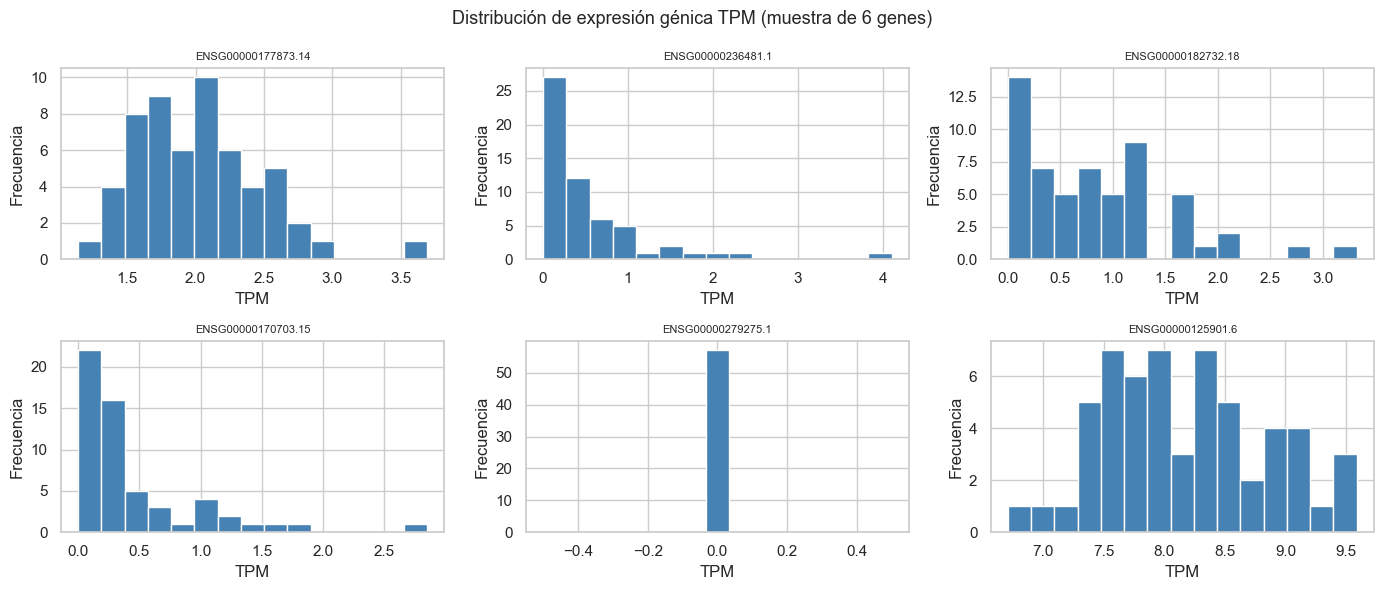

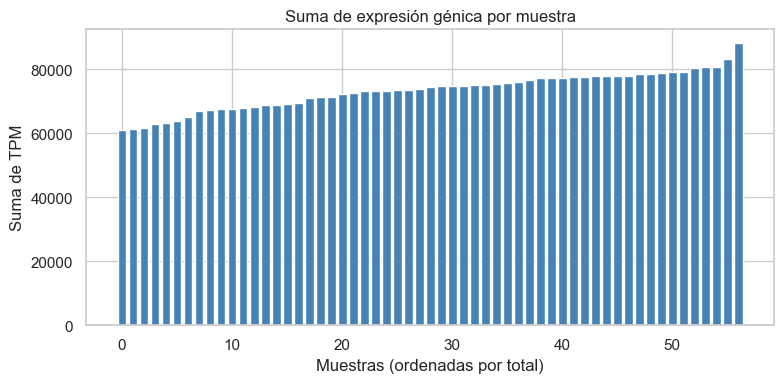

Media de suma por muestra: 73,223
Desviación estándar:       5,873
Rango:                     60,826 – 87,981
Muestras con suma > media+3σ (90,841): []


In [4]:
# =========================
# 3. Análisis de distribuciones y valores atípicos
# =========================

# --- Distribución de expresión (muestra aleatoria de 6 genes) ---
np.random.seed(42)
sample_genes = np.random.choice(expr.index, size=min(6, len(expr)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle('Distribución de expresión génica TPM (muestra de 6 genes)', fontsize=13)
for ax, gene in zip(axes.flat, sample_genes):
    vals = expr.loc[gene].dropna().values
    ax.hist(vals, bins=15, edgecolor='white', color='steelblue')
    ax.set_title(str(gene)[:20], fontsize=8)
    ax.set_xlabel('TPM')
    ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# --- Distribución de la suma de expresión por muestra ---
sample_totals = expr.sum(axis=0)
plt.figure(figsize=(8, 4))
plt.bar(range(len(sample_totals)), sorted(sample_totals.values), color='steelblue', edgecolor='white')
plt.xlabel('Muestras (ordenadas por total)')
plt.ylabel('Suma de TPM')
plt.title('Suma de expresión génica por muestra')
plt.tight_layout()
plt.show()

print(f'Media de suma por muestra: {sample_totals.mean():,.0f}')
print(f'Desviación estándar:       {sample_totals.std():,.0f}')
print(f'Rango:                     {sample_totals.min():,.0f} – {sample_totals.max():,.0f}')
outlier_threshold = sample_totals.mean() + 3 * sample_totals.std()
outlier_samples = sample_totals[sample_totals > outlier_threshold]
print(f'Muestras con suma > media+3σ ({outlier_threshold:,.0f}): {list(outlier_samples.index)}')


In [5]:
# =========================
# 4. Valores faltantes y coincidencia de muestras
# =========================

# Valores faltantes en expresión génica
missing_by_gene   = expr.isna().sum(axis=1)   # por gen (filas)
missing_by_sample = expr.isna().sum(axis=0)   # por muestra (cols)
print('Genes con al menos un NaN:', (missing_by_gene > 0).sum())
print('Muestras con al menos un NaN:', (missing_by_sample > 0).sum())

# Coincidencia de muestras entre archivos
expr_samples     = set(expr.columns)
clinical_samples = set(clinical['sample'])
survival_samples = set(survival['sample'])

print(f'\nMuestras en expresión:    {len(expr_samples)}')
print(f'Muestras en clínico:      {len(clinical_samples)}')
print(f'Muestras en supervivencia: {len(survival_samples)}')
print(f'\nEn expresión pero no en clínico:       {expr_samples - clinical_samples}')
print(f'En clínico pero no en expresión:       {clinical_samples - expr_samples}')
print(f'En expresión pero no en supervivencia: {expr_samples - survival_samples}')

# Unir clínico y supervivencia
clinical_survival = clinical.merge(survival, on='sample', how='left')
print(f'\nTabla clínica + supervivencia: {clinical_survival.shape}')
display(clinical_survival.head(3))


Genes con al menos un NaN: 0
Muestras con al menos un NaN: 0

Muestras en expresión:    57
Muestras en clínico:      57
Muestras en supervivencia: 55

En expresión pero no en clínico:       set()
En clínico pero no en expresión:       set()
En expresión pero no en supervivencia: {'TCGA-ND-A4WA-01A', 'TCGA-QN-A5NN-01A'}

Tabla clínica + supervivencia: (57, 67)


,sample,id,disease_type,case_id,submitter_id,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,...,initial_weight.samples,preservation_method.samples,pathology_report_uuid.samples,oct_embedded.samples,specimen_type.samples,is_ffpe.samples,tissue_type.samples,OS.time,OS,_PATIENT
0,TCGA-N5-A4RM-01A,254f6921-82ac-4fe1-b1b4-ace94c420d05,Complex Mixed and Stromal Neoplasms,254f6921-82ac-4fe1-b1b4-ace94c420d05,TCGA-N5-A4RM,"Uterus, NOS",Not Reported,white,female,not hispanic or latino,...,250.0,OCT,C188B8E8-B564-45A6-B356-B4D7C64B8DA5,True,Solid Tissue,False,Tumor,148.0,1.0,TCGA-N5-A4RM
1,TCGA-N9-A4Q7-01A,9f15bf13-11d2-400f-b6f9-c8be0a57c763,Complex Mixed and Stromal Neoplasms,9f15bf13-11d2-400f-b6f9-c8be0a57c763,TCGA-N9-A4Q7,"Uterus, NOS",Not Reported,black or african american,female,not reported,...,420.0,Unknown,0E5E42BD-AB48-4889-BFC8-1D6E6657CB85,False,Solid Tissue,False,Tumor,604.0,0.0,TCGA-N9-A4Q7
2,TCGA-N6-A4VD-01A,14213209-2217-4812-9a19-d9b2b6718467,Complex Mixed and Stromal Neoplasms,14213209-2217-4812-9a19-d9b2b6718467,TCGA-N6-A4VD,"Uterus, NOS",Not Reported,white,female,not hispanic or latino,...,400.0,OCT,B1D9BFB6-3943-457E-ACBC-89504A5CD7E0,True,Solid Tissue,False,Tumor,112.0,1.0,TCGA-N6-A4VD


### Observaciones

- El dataset de expresión génica tiene muy pocos o ningún valor faltante, gracias al proceso estandarizado de procesamiento de TCGA con el pipeline STAR.
- Las 57 muestras de expresión coinciden perfectamente con el archivo clínico. Solo 2 muestras carecen de datos de supervivencia.
- Las distribuciones de TPM por gen suelen ser asimétricas a la derecha (cola larga hacia valores altos), lo que es característico de datos de RNA-seq. Se aplicará una transformación logarítmica implícita a través de la selección de alta varianza antes del escalamiento.
- La suma de expresión por muestra no muestra valores atípicos graves (≥ 3 desviaciones estándar), indicando que la normalización TPM fue efectiva.


## 3. Preparación y tratamiento de los datos

Antes de aplicar PCA y clustering, se realizaron los siguientes pasos de preprocesamiento:

1. **Transposición:** la matriz de expresión se transpuso de (genes × muestras) a (muestras × genes) para que cada fila represente un paciente.
2. **Eliminación de genes con NaN:** se eliminaron genes con cualquier valor faltante (columnas del DataFrame transpuesto).
3. **Transformación log1p:** se aplicó log₁p(TPM) = log(TPM + 1). Los datos 
   de expresión RNA-seq siguen una distribución aproximadamente log-normal 
   (Bullard et al., 2010); sin esta transformación, los genes con TPM absolutos 
   altos dominarían el PCA. La transformación estabiliza la varianza y hace los 
   datos más adecuados para métodos basados en distancias euclídeas.

4. **Selección de genes de alta varianza:** se retuvieron los 2,000 genes con 
   mayor varianza calculada sobre los datos log-transformados, práctica estándar 
   en análisis de expresión génica (Ringnér, 2008).

5. **Escalamiento estándar:** se aplicó `StandardScaler` (media 0, σ = 1) 
   mediante scikit-learn (Pedregosa et al., 2011), requisito previo al PCA para 
   evitar que la magnitud absoluta de expresión domine las componentes principales.

In [ ]:
# =========================
# 5. Transponer y limpiar expresión génica
# =========================

X = expr.T
X = X.apply(pd.to_numeric, errors='coerce')
print('Matriz transpuesta (muestras × genes):', X.shape)

# Eliminar genes con NaN
X_clean = X.dropna(axis=1)
print('Después de eliminar genes con NaN:    ', X_clean.shape)

X_log = np.log1p(X_clean)
print("Matriz log1p:", X_log.shape)

# Selección por varianza
top_n = 2000

# Selección por varianza (sobre datos log-transformados)
gene_variances = X_log.var(axis=0)
top_genes      = gene_variances.sort_values(ascending=False).head(top_n).index
X_filtered     = X_log[top_genes]   # ← ahora X_filtered viene de X_log, no de X_clean

print(f'Después de seleccionar top-{top_n} por varianza:', X_filtered.shape)

# Escalamiento
scaler          = StandardScaler()
X_scaled_array  = scaler.fit_transform(X_filtered)
X_scaled        = pd.DataFrame(X_scaled_array, index=X_filtered.index, columns=X_filtered.columns)
print('Matriz escalada:', X_scaled.shape)

# Tabla de muestras base
samples = pd.DataFrame({'sample': X.index})

display(X_scaled.head(3))


Matriz transpuesta (muestras × genes): (57, 60660)
Después de eliminar genes con NaN:     (57, 60660)
Después de seleccionar top-2000 por varianza: (57, 2000)
Matriz escalada: (57, 2000)


Ensembl_ID,ENSG00000168530.16,ENSG00000122180.5,ENSG00000180209.12,ENSG00000159251.8,ENSG00000101470.10,ENSG00000185559.16,ENSG00000143632.14,ENSG00000133055.9,ENSG00000198336.9,ENSG00000109063.15,...,ENSG00000205502.4,ENSG00000204140.10,ENSG00000164330.17,ENSG00000163141.20,ENSG00000134138.20,ENSG00000165863.17,ENSG00000175592.9,ENSG00000095752.7,ENSG00000210140.1,ENSG00000198075.10
TCGA-NF-A4X2-01A,-0.712012,-0.762284,-0.796799,-0.994379,-1.227748,-1.436362,-0.187554,-0.828106,-0.812356,-0.802932,...,-1.199889,-0.794395,-0.440778,-0.756778,-0.158817,-1.839837,1.529730,-0.460199,-2.457817,-1.939475
TCGA-N5-A4RA-01A,1.642992,1.704451,1.732781,1.544618,1.899617,0.837041,1.972697,1.662096,1.734534,1.760032,...,-1.136446,-0.794395,-1.176071,-0.941152,-0.931988,-0.830444,-0.590286,0.911860,-0.296033,-0.067688
TCGA-NG-A4VU-01A,1.733531,1.541884,1.877608,1.890400,1.937974,1.691492,2.141829,1.883332,1.757573,2.161308,...,-1.331813,-0.794395,-0.308624,-0.824053,-0.851041,-1.889043,-1.464864,-1.435286,1.125644,0.360752


La selección de 2,000 genes de mayor varianza reduce la dimensionalidad de ~60,660 a 2,000 features sin eliminar información biológica relevante, ya que genes con varianza cercana a cero aportan poco poder discriminativo. El escalamiento estándar es indispensable antes del PCA: sin él, genes con valores TPM absolutos más altos dominarían las componentes principales, independientemente de su relevancia biológica.


## 4. Reducción de dimensionalidad mediante PCA

Se aplica PCA sobre la matriz de expresión escalada. El objetivo es tanto analizar cuánta varianza capturan las primeras componentes principales, como visualizar si existe estructura o separación entre pacientes en un espacio de baja dimensión. El PCA se ajusta con el máximo número posible de componentes (mín(57, 2000) = 57) y lugo se selecciona el subconjunto mínimo necesario para conservar al menos el 80% de la varianza acumulada, que se usará como representación para el clustering. El Análisis de Componentes Principales (PCA) es una técnica de reducción de 
dimensionalidad que proyecta los datos en un subespacio de menor dimensión 
maximizando la varianza retenida.


,componente,varianza_explicada,varianza_acumulada
0,1,0.186988,0.186988
1,2,0.080465,0.267453
2,3,0.066872,0.334326
3,4,0.052752,0.387078
4,5,0.046593,0.433671
5,6,0.032592,0.466263
6,7,0.028111,0.494375
7,8,0.026789,0.521164
8,9,0.024849,0.546013
9,10,0.022281,0.568294


,varianza_objetivo,componentes_necesarios
0,0.60,12
1,0.70,18
2,0.80,27
3,0.90,39
4,0.95,47


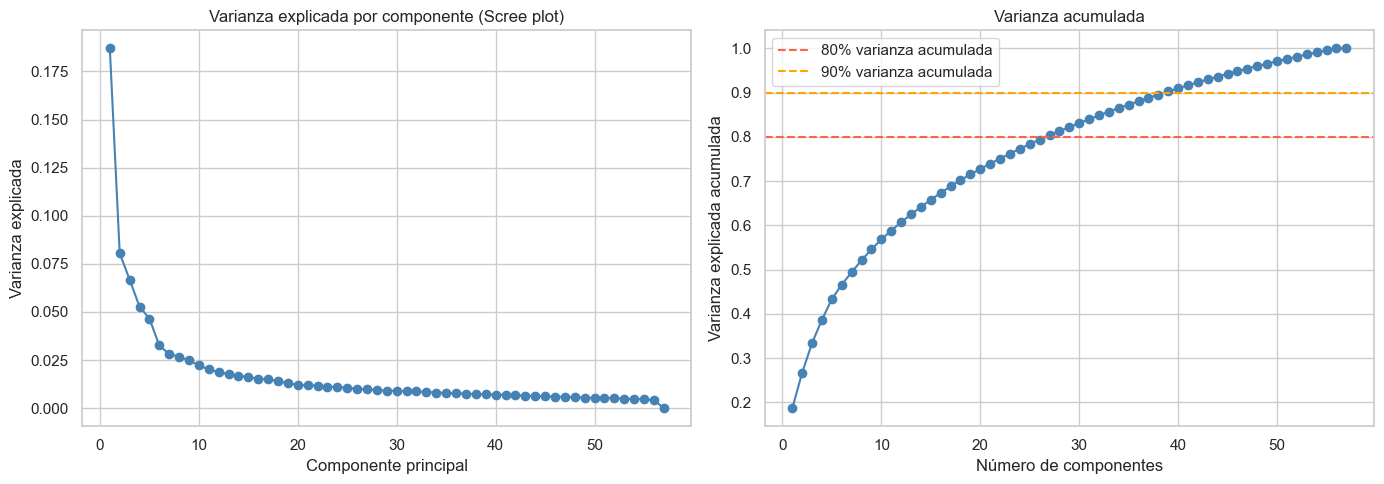

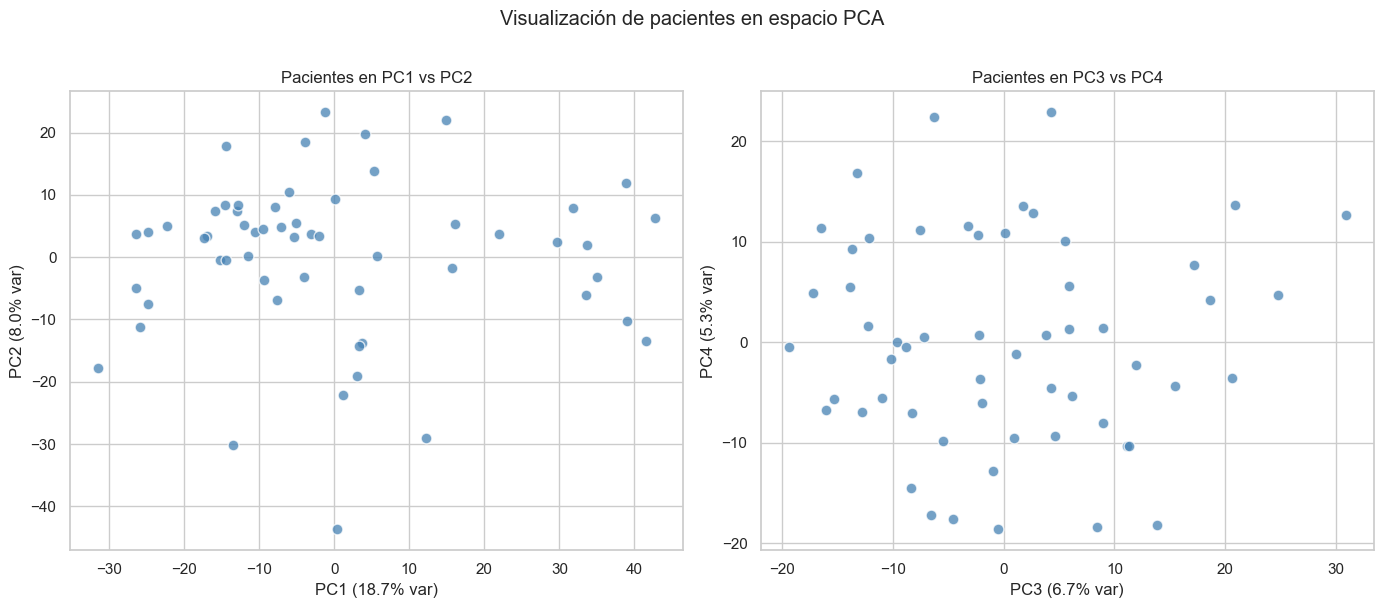

In [7]:
# =========================
# 6. PCA completo: varianza explicada
# =========================

max_components = min(X_scaled.shape[0], X_scaled.shape[1])

pca_full             = PCA(n_components=max_components)
X_pca_full_array     = pca_full.fit_transform(X_scaled)
explained_variance   = pca_full.explained_variance_ratio_
cumulative_variance  = np.cumsum(explained_variance)

pca_variance = pd.DataFrame({
    'componente':       np.arange(1, len(explained_variance) + 1),
    'varianza_explicada': explained_variance,
    'varianza_acumulada': cumulative_variance
})

display(pca_variance.head(15))

# Componentes necesarios para distintos porcentajes
variance_targets = [0.60, 0.70, 0.80, 0.90, 0.95]
components_needed = pd.DataFrame([{
    'varianza_objetivo': t,
    'componentes_necesarios': int(np.searchsorted(cumulative_variance, t) + 1)
} for t in variance_targets])
display(components_needed)

# Guardar
pca_variance.to_csv(results_dir / 'pca_varianza_explicada.csv', index=False)
components_needed.to_csv(results_dir / 'pca_componentes_necesarios.csv', index=False)

# ─── Gráficas ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pca_variance['componente'], pca_variance['varianza_explicada'], marker='o', color='steelblue')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza explicada por componente (Scree plot)')

axes[1].plot(pca_variance['componente'], pca_variance['varianza_acumulada'], marker='o', color='steelblue')
for lvl, col in zip([0.80, 0.90], ['tomato', 'orange']):
    axes[1].axhline(lvl, linestyle='--', color=col, label=f'{int(lvl*100)}% varianza acumulada')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza explicada acumulada')
axes[1].set_title('Varianza acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

# ─── Visualización PC1 vs PC2, PC3 vs PC4 ───
pca_df = pd.DataFrame(
    X_pca_full_array[:, :min(4, max_components)],
    index=X_scaled.index,
    columns=[f'PC{i}' for i in range(1, min(4, max_components) + 1)]
)
pca_df['sample'] = pca_df.index

# Compatibilidad con celdas posteriores
pca_2d = pca_df[['PC1', 'PC2', 'sample']].copy()

n_pairs = 2 if max_components >= 4 else 1
fig, axes = plt.subplots(1, n_pairs, figsize=(7 * n_pairs, 6))
if n_pairs == 1:
    axes = [axes]

pc_pairs = [('PC1', 'PC2'), ('PC3', 'PC4')] if max_components >= 4 else [('PC1', 'PC2')]
for ax, (pcx, pcy) in zip(axes, pc_pairs):
    xi = int(pcx[2]) - 1
    yi = int(pcy[2]) - 1
    ax.scatter(pca_df[pcx], pca_df[pcy], alpha=0.75, s=60, color='steelblue', edgecolors='white')
    ax.set_xlabel(f'{pcx} ({explained_variance[xi]*100:.1f}% var)')
    ax.set_ylabel(f'{pcy} ({explained_variance[yi]*100:.1f}% var)')
    ax.set_title(f'Pacientes en {pcx} vs {pcy}')

plt.suptitle('Visualización de pacientes en espacio PCA', y=1.01)
plt.tight_layout()
plt.show()


### Interpretación del PCA

- PC1 explica el **18.7%** de la varianza y PC2 el **8.0%** (total acumulado: 26.7%).
- En el scatter PC1 vs PC2 se observa muy poco una separación clara entre
  subgrupos de pacientes. 
- PC3 vs PC4 no muestra estructura adicional.

### Selección del número de componentes

Se selecciona el número mínimo de componentes principales necesario para conservar **al menos el 80% de la varianza acumulada**. Esta decisión equilibra dos objetivos:

- **Retención de información:** conservar 80% asegura que los patrones dominantes del perfil de expresión génica estén representados en el espacio reducido.
- **Reducción de ruido:** con 57 muestras frente a 2,000 genes, las componentes de orden alto capturan principalmente ruido estadístico. Descartar estas componentes mejora la calidad del clustering.

La elección de 80% fue hecha mediante pruebas experimentales y comparativa de métricas resultantes. Adicionalmente se generó una oración condicional que indica que, si el número de componentes es excesivo (>20), se reduzca la varianza objetivo a 70%.

In [8]:
# =========================
# 7. Crear matriz PCA reducida para clustering
# =========================

variance_target = 0.80
n_components_selected = int(np.searchsorted(cumulative_variance, variance_target) + 1)

# Si el número de componentes es excessivo, bajar umbral
if n_components_selected > 20:
    variance_target = 0.70
    n_components_selected = int(np.searchsorted(cumulative_variance, variance_target) + 1)
    print(f'Umbral ajustado a {variance_target} por exceso de componentes.')

pca_selected       = PCA(n_components=n_components_selected)
X_pca_selected_arr = pca_selected.fit_transform(X_scaled)

pca_columns    = [f'PC{i}' for i in range(1, n_components_selected + 1)]
X_pca_selected = pd.DataFrame(X_pca_selected_arr, index=X_scaled.index, columns=pca_columns)

print(f'Componentes seleccionados: {n_components_selected}')
print(f'Varianza acumulada conservada: {cumulative_variance[n_components_selected-1]:.4f} ({cumulative_variance[n_components_selected-1]*100:.1f}%)')
display(X_pca_selected.head(3))

X_pca_selected.to_csv(results_dir / 'matriz_pca_para_clustering.csv')


Umbral ajustado a 0.7 por exceso de componentes.
Componentes seleccionados: 18
Varianza acumulada conservada: 0.7024 (70.2%)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
TCGA-NF-A4X2-01A,1.154487,-22.139034,-4.581484,-17.603103,-14.477585,4.656690,-6.044541,-1.721195,7.961960,3.702653,-8.503054,-3.943762,-1.499271,10.173841,1.986535,4.883448,-2.426001,-0.494498
TCGA-N5-A4RA-01A,34.973335,-3.163246,8.975333,1.467783,7.575166,-4.685415,2.111622,1.478444,-5.030425,4.942351,3.678308,-1.723565,-1.774366,-7.059501,-3.256950,-4.527868,1.159930,2.617341
TCGA-NG-A4VU-01A,39.039292,-10.201123,8.960739,-8.000599,17.316017,9.983916,-8.225443,-1.265199,2.681918,5.734663,-6.036401,3.311405,-3.102156,-1.147016,-5.295729,2.416216,6.055745,0.627871


## 5. Construcción y comparación de modelos de clustering

Se construyen dos modelos de clustering sobre la representación PCA reducida: **K-means** y **clustering jerárquico aglomerativo con enlace Ward**. Primero se determina el numero óptimo de clusters `k` evaluando la inercia (método del codo) y el silhouette score para K-means. Luego se aplica clustering jerárquico con el mismo `k` para poder comparar directamente ambos métodos.

### Justificación de los métodos
- **K-means** (MacQueen, 1967) particiona los datos minimizando la inercia 
  intra-cluster. Asume clusters de forma aproximadamente esférica y es 
  computacionalmente eficiente. Se usa `n_init=50` para reducir la dependencia 
  de la inicialización aleatoria (Pedregosa et al., 2011).

- **Hierarchical clustering con enlace Ward** (Ward, 1963) fusiona clusters 
  minimizando el incremento de varianza intra-cluster en cada paso. Produce 
  resultados reproducibles y permite visualización mediante dendrograma.

La calidad de los clusters se evalúa con el **Silhouette score** (Rousseeuw, 
1987), que mide la cohesión interna y la separación entre clusters (rango: 
−1 a 1, mayor es mejor). La concordancia entre modelos se mide con el 
**Adjusted Rand Index** (Hubert & Arabie, 1985).

,k,inercia,silhouette
0,2,63748.497555,0.199225
1,3,56936.017736,0.194301
2,4,51615.280408,0.150273
3,5,47783.822984,0.160620
4,6,44734.972984,0.148560
5,7,41664.055983,0.141570
6,8,39711.987705,0.148358


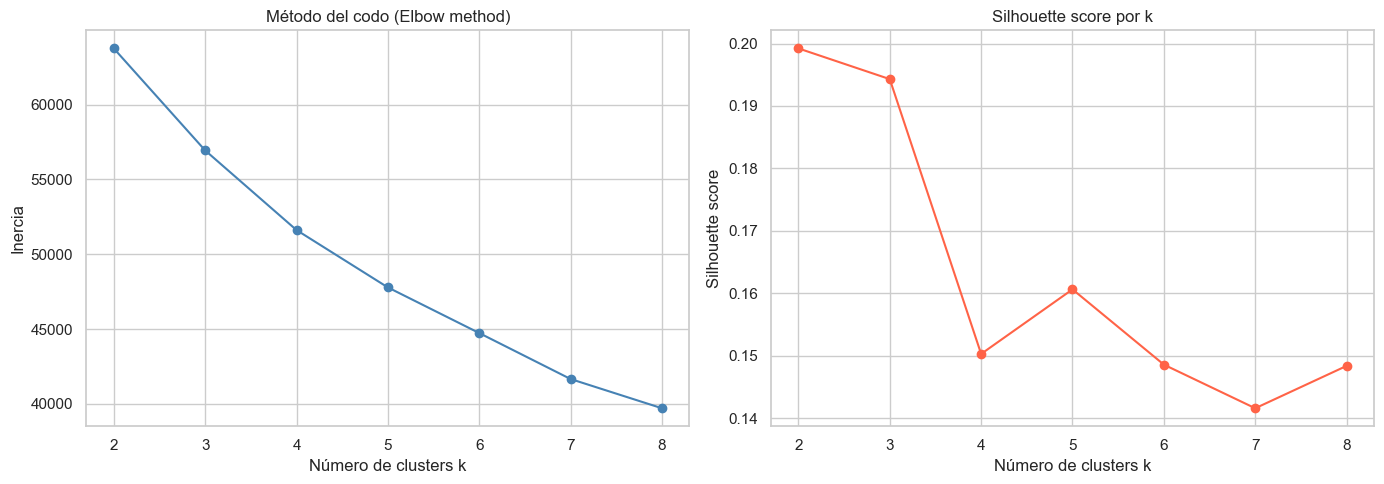

k sugerido por silhouette: 2


In [9]:
# =========================
# 8. K-means: selección del número de clusters
# =========================

max_k    = min(8, X_pca_selected.shape[0] - 1)
k_values = range(2, max_k + 1)

kmeans_results = []
for k in k_values:
    model     = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels    = model.fit_predict(X_pca_selected)
    kmeans_results.append({
        'k':          k,
        'inercia':    model.inertia_,
        'silhouette': silhouette_score(X_pca_selected, labels)
    })

kmeans_results = pd.DataFrame(kmeans_results)
display(kmeans_results)
kmeans_results.to_csv(results_dir / 'kmeans_metricas_k.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(kmeans_results['k'], kmeans_results['inercia'], marker='o', color='steelblue')
axes[0].set_xlabel('Número de clusters k')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo (Elbow method)')

axes[1].plot(kmeans_results['k'], kmeans_results['silhouette'], marker='o', color='tomato')
axes[1].set_xlabel('Número de clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score por k')

plt.tight_layout()
plt.show()

best_k = int(kmeans_results.loc[kmeans_results['silhouette'].idxmax(), 'k'])
print(f'k sugerido por silhouette: {best_k}')


kmeans_cluster
0    44
1    13
Name: Pacientes, dtype: int64

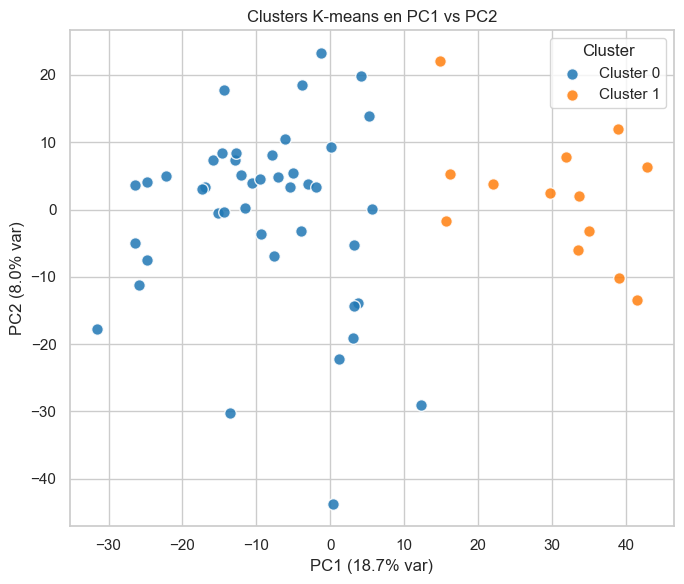

In [10]:
# =========================
# 9. Modelo final de K-means
# =========================

kmeans_final  = KMeans(n_clusters=best_k, random_state=42, n_init=50)
kmeans_labels = kmeans_final.fit_predict(X_pca_selected)

samples_kmeans = pd.DataFrame({'sample': X_pca_selected.index, 'kmeans_cluster': kmeans_labels})
display(samples_kmeans['kmeans_cluster'].value_counts().sort_index().rename('Pacientes'))

# Visualización con mapa de color discreto
pca_2d_kmeans = pca_2d.merge(samples_kmeans, on='sample', how='left')
cmap = cm.get_cmap('tab10', best_k)
colors = [cmap(c) for c in pca_2d_kmeans['kmeans_cluster']]

fig, ax = plt.subplots(figsize=(7, 6))
for cluster_id in sorted(pca_2d_kmeans['kmeans_cluster'].unique()):
    mask = pca_2d_kmeans['kmeans_cluster'] == cluster_id
    ax.scatter(
        pca_2d_kmeans.loc[mask, 'PC1'],
        pca_2d_kmeans.loc[mask, 'PC2'],
        label=f'Cluster {cluster_id}',
        s=70, alpha=0.85, edgecolors='white'
    )
ax.set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}% var)')
ax.set_title('Clusters K-means en PC1 vs PC2')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()


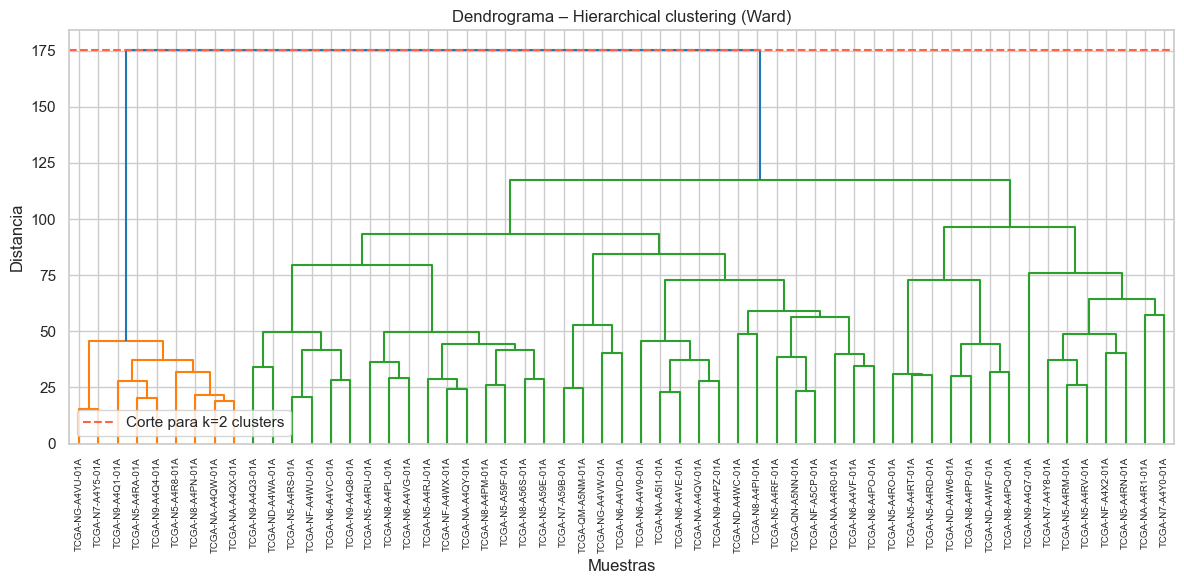

hierarchical_cluster
0    48
1     9
Name: Pacientes, dtype: int64

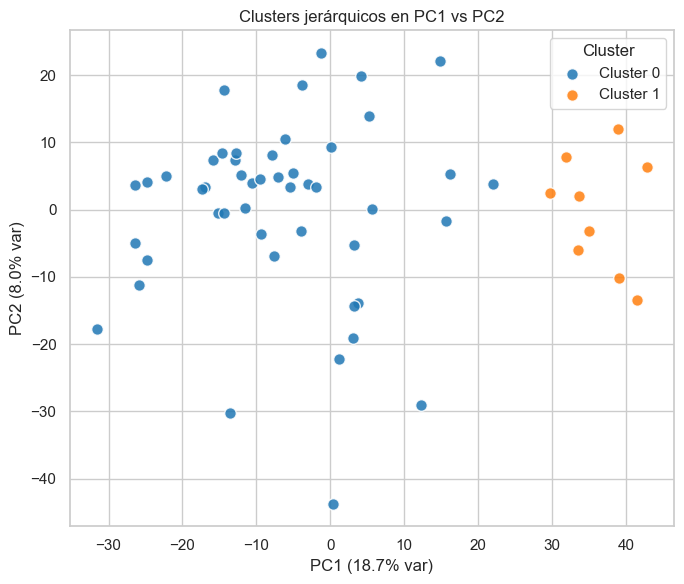

In [11]:
# =========================
# 10. Hierarchical clustering
# =========================

linkage_matrix = linkage(X_pca_selected, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=X_pca_selected.index.tolist(),
           leaf_rotation=90, leaf_font_size=7)
plt.axhline(y=linkage_matrix[-(best_k-1), 2], linestyle='--', color='tomato',
            label=f'Corte para k={best_k} clusters')
plt.title('Dendrograma – Hierarchical clustering (Ward)')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.legend()
plt.tight_layout()
plt.show()

hierarchical_final  = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hierarchical_labels = hierarchical_final.fit_predict(X_pca_selected)

samples_hierarchical = pd.DataFrame({
    'sample': X_pca_selected.index,
    'hierarchical_cluster': hierarchical_labels
})
display(samples_hierarchical['hierarchical_cluster'].value_counts().sort_index().rename('Pacientes'))

# Visualización con mapa de color discreto
pca_2d_hierarchical = pca_2d.merge(samples_hierarchical, on='sample', how='left')

fig, ax = plt.subplots(figsize=(7, 6))
for cluster_id in sorted(pca_2d_hierarchical['hierarchical_cluster'].unique()):
    mask = pca_2d_hierarchical['hierarchical_cluster'] == cluster_id
    ax.scatter(
        pca_2d_hierarchical.loc[mask, 'PC1'],
        pca_2d_hierarchical.loc[mask, 'PC2'],
        label=f'Cluster {cluster_id}',
        s=70, alpha=0.85, edgecolors='white'
    )
ax.set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}% var)')
ax.set_title('Clusters jerárquicos en PC1 vs PC2')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()


In [12]:
# =========================
# 11. Comparación entre K-means y hierarchical clustering
# =========================

kmeans_silhouette       = silhouette_score(X_pca_selected, kmeans_labels)
hierarchical_silhouette = silhouette_score(X_pca_selected, hierarchical_labels)
ari                     = adjusted_rand_score(kmeans_labels, hierarchical_labels)

cluster_comparison = pd.DataFrame({
    'Modelo':      ['K-means', 'Hierarchical clustering'],
    'k':           [best_k, best_k],
    'Silhouette':  [kmeans_silhouette, hierarchical_silhouette]
})
display(cluster_comparison)
print(f'Adjusted Rand Index (ARI) entre ambos modelos: {ari:.4f}')

comparison_table = pd.crosstab(
    samples_kmeans['kmeans_cluster'],
    samples_hierarchical['hierarchical_cluster'],
    rownames=['K-means'],
    colnames=['Hierarchical']
)
display(comparison_table)

cluster_comparison.to_csv(results_dir / 'comparacion_modelos_clustering.csv', index=False)
comparison_table.to_csv(results_dir / 'tabla_comparacion_kmeans_hierarchical.csv')

# Selección del modelo final
if kmeans_silhouette >= hierarchical_silhouette:
    selected_model_name = 'K-means'
    selected_labels     = kmeans_labels
else:
    selected_model_name = 'Hierarchical clustering'
    selected_labels     = hierarchical_labels

print(f'\nModelo seleccionado: {selected_model_name} (Silhouette = {max(kmeans_silhouette, hierarchical_silhouette):.4f})')


,Modelo,k,Silhouette
0,K-means,2,0.199225
1,Hierarchical clustering,2,0.211486


Adjusted Rand Index (ARI) entre ambos modelos: 0.6947


Hierarchical,0,1
K-means,,
0,44,0
1,4,9



Modelo seleccionado: Hierarchical clustering (Silhouette = 0.2115)


### Selección del modelo final

- K-means obtuvo Silhouette = 0.199; Hierarchical = 0.211.
- El ARI entre ambos modelos fue 0.69, indicando moderada-alta concordancia.
- Se selecciona **Hierarchical** por tener mayor Silhouette 
(0.211 vs 0.199), lo que indica que sus clusters son más 
compactos y mejor separados en el espacio PCA.

In [13]:
# =========================
# 12b. Crear tabla de asignación de clusters (modelo seleccionado)
# =========================

samples_clusters = pd.DataFrame({
    'sample':  X_pca_selected.index,
    'cluster': selected_labels
})

print(f'Modelo: {selected_model_name} | k = {best_k}')
print('Pacientes por cluster:')
display(samples_clusters['cluster'].value_counts().sort_index().rename('Pacientes'))

samples_clusters.to_csv(results_dir / 'asignacion_clusters_final.csv', index=False)


Modelo: Hierarchical clustering | k = 2
Pacientes por cluster:


cluster
0    48
1     9
Name: Pacientes, dtype: int64

## 6. Interpretación de los clusters – análisis de genes

A partir del modelo de clustering seleccionado, se comparan los perfiles de expresión génica entre clusters para identificar los genes que más contribuyen a diferenciar los grupos. Se utiliza:

- **Prueba t de Welch** si hay exactamente 2 clusters (más potente que Mann-Whitney para este tamaño de muestra cuando los grupos son desiguales).
- **Kruskal-Wallis** si hay más de 2 clusters (prueba no paramétrica equivalente al ANOVA).
- Corrección por comparaciones múltiples mediante **Benjamini-Hochberg (FDR)** para controlar la tasa de falsos positivos al comparar 2,000 genes simultáneamente.

El tamaño del efecto se estima como la diferencia entre la media más alta y la más baja entre clusters (`max_mean – min_mean`), permitiendo ordenar los genes tanto por significancia estadística como por relevancia biológica.


In [ ]:
# =========================
# 12. Análisis estadístico de genes entre clusters
# =========================

cluster_series = pd.Series(selected_labels, index=X_filtered.index, name='cluster')

def benjamini_hochberg(p_values):
    """Corrección FDR Benjamini-Hochberg."""
    p_values = np.asarray(p_values, dtype=float)
    p_values = np.where(np.isnan(p_values), 1.0, p_values)
    n     = len(p_values)
    order = np.argsort(p_values)
    ranks = np.empty(n, dtype=int)
    ranks[order] = np.arange(1, n + 1)
    adjusted = p_values * n / ranks
    adj_sorted = adjusted[order]
    adj_sorted = np.minimum.accumulate(adj_sorted[::-1])[::-1]
    adjusted_final = np.empty(n)
    adjusted_final[order] = adj_sorted
    return np.clip(adjusted_final, 0, 1)

gene_results     = []
unique_clusters  = sorted(cluster_series.unique())

for gene in X_filtered.columns:
    gene_values = X_filtered[gene]
    groups      = [gene_values[cluster_series == c].dropna() for c in unique_clusters]
    means_dict  = {f'mean_cluster_{c}': gene_values[cluster_series == c].mean() for c in unique_clusters}
    valid       = [g for g in groups if len(g) >= 2]

    if len(valid) < 2:
        statistic, p_value = np.nan, np.nan
    elif len(unique_clusters) == 2:
        statistic, p_value = stats.ttest_ind(valid[0], valid[1], equal_var=False, nan_policy='omit')
    else:
        statistic, p_value = stats.kruskal(*valid)

    # Reemplaza las líneas de effect_size con esto:
    means = list(means_dict.values())

    # Log2 fold-change: log2(media_mayor / media_menor)
    # Se añade pseudocuenta 1 para evitar log(0)
    mean_max = np.nanmax(means) + 1
    mean_min = np.nanmin(means) + 1
    log2fc   = np.log2(mean_max / mean_min)

    effect_size = log2fc   # reemplaza la diferencia cruda
    top_cluster = unique_clusters[int(np.nanargmax(means))]

    gene_results.append({
        'gene': gene, 'statistic': statistic, 'p_value': p_value,
        'log2_fold_change': effect_size,          # ← renombrar también aquí
        'cluster_with_highest_expression': top_cluster,
        **means_dict
    })

gene_results = pd.DataFrame(gene_results)
gene_results['p_adjusted_bh'] = benjamini_hochberg(gene_results['p_value'])
gene_results = gene_results.sort_values(
    ['p_adjusted_bh', 'log2_fold_change'],
    ascending=[True, False]
)

display(gene_results.head(25))
gene_results.to_csv(results_dir / 'genes_diferenciales_por_cluster.csv', index=False)

sig_genes = (gene_results['p_adjusted_bh'] < 0.05).sum()
print(f'Genes con FDR-BH < 0.05: {sig_genes} de {len(gene_results)}')


,gene,statistic,p_value,effect_size_max_minus_min,cluster_with_highest_expression,mean_cluster_0,mean_cluster_1,p_adjusted_bh
4,ENSG00000101470.10,-22.548595,1.996731e-29,8.710163,1,3.742286,12.452449,3.993461e-26
22,ENSG00000135902.10,-21.232642,4.613042e-28,6.999209,1,1.621562,8.620771,4.613042e-25
2,ENSG00000180209.12,-19.378247,7.767914e-26,8.908003,1,3.488670,12.396673,5.178609e-23
1,ENSG00000122180.5,-19.164409,1.368359e-25,8.996711,1,2.147396,11.144107,6.841796e-23
3,ENSG00000159251.8,-18.296034,9.756714e-25,8.553220,1,2.920227,11.473447,3.902685e-22
15,ENSG00000118729.12,-21.764617,2.024602e-24,7.589429,1,1.620463,9.209892,6.748672e-22
23,ENSG00000124701.5,-22.519806,3.785027e-24,7.372711,1,1.237715,8.610425,1.081436e-21
0,ENSG00000168530.16,-18.107383,1.067336e-23,9.585142,1,2.333957,11.919099,2.668339e-21
9,ENSG00000109063.15,-19.183981,1.827021e-23,7.829260,1,2.646020,10.475280,4.039009e-21
28,ENSG00000165917.10,-18.346656,2.019504e-23,6.533861,1,1.915570,8.449431,4.039009e-21


Genes con FDR-BH < 0.05: 994 de 2000


In [15]:
# =========================
# 13. Intentar agregar nombres de genes si existe archivo de mapping
# =========================

def try_load_gene_mapping(data_dir):
    """
    Busca archivos de mapping de genes en la carpeta data_bases.
    Si no existe uno, devuelve None.
    """
    mapping_patterns = [
        "*mapping*.tsv",
        "*mapping*.tsv.gz",
        "*gencode*.tsv",
        "*gencode*.tsv.gz",
        "*gene_mapping*.tsv",
        "*gene_mapping*.tsv.gz"
    ]

    mapping_files = []
    for pattern in mapping_patterns:
        mapping_files.extend(list(data_dir.glob(pattern)))

    mapping_files = list(dict.fromkeys(mapping_files))

    if len(mapping_files) == 0:
        print("No se encontró archivo de ID/Gene Mapping en la carpeta data_bases.")
        print("Por ahora se conservarán los identificadores Ensembl.")
        return None

    mapping_path = mapping_files[0]
    print(f"Archivo de mapping encontrado: {mapping_path}")

    mapping = pd.read_csv(mapping_path, sep="\t", compression="infer")
    return mapping

def add_gene_symbols(gene_results, mapping):
    """
    Intenta unir símbolos de genes al resultado estadístico.
    Funciona con varios formatos comunes de columnas.
    """
    if mapping is None:
        return gene_results

    mapping_cols = list(mapping.columns)
    print("Columnas disponibles en mapping:")
    print(mapping_cols)

    possible_id_cols = [
        "Ensembl_ID", "ensembl_id", "gene_id", "id", "ID", "ensembl_gene_id"
    ]

    possible_symbol_cols = [
        "gene", "gene_name", "symbol", "gene_symbol", "external_gene_name", "name"
    ]

    id_col = next((col for col in possible_id_cols if col in mapping_cols), None)
    symbol_col = next((col for col in possible_symbol_cols if col in mapping_cols), None)

    if id_col is None or symbol_col is None:
        print("No se pudieron identificar automáticamente las columnas de ID y símbolo.")
        print("Se conservarán los identificadores Ensembl.")
        return gene_results

    mapping_copy = mapping[[id_col, symbol_col]].copy()
    mapping_copy.columns = ["ensembl_id_clean", "gene_symbol"]
    mapping_copy["ensembl_id_clean"] = mapping_copy["ensembl_id_clean"].astype(str).str.replace(
        r"\.\d+$",
        "",
        regex=True
    )

    gene_results_copy = gene_results.copy()
    gene_results_copy["ensembl_id_clean"] = gene_results_copy["gene"].astype(str).str.replace(
        r"\.\d+$",
        "",
        regex=True
    )

    gene_results_mapped = gene_results_copy.merge(
        mapping_copy.drop_duplicates("ensembl_id_clean"),
        on="ensembl_id_clean",
        how="left"
    )

    first_columns = ["gene", "ensembl_id_clean", "gene_symbol"]
    other_columns = [col for col in gene_results_mapped.columns if col not in first_columns]
    gene_results_mapped = gene_results_mapped[first_columns + other_columns]

    return gene_results_mapped

mapping = try_load_gene_mapping(data_dir)
gene_results_mapped = add_gene_symbols(gene_results, mapping)

display(gene_results_mapped.head(25))

gene_results_mapped.to_csv(results_dir / "genes_diferenciales_por_cluster_con_mapping.csv", index=False)


No se encontró archivo de ID/Gene Mapping en la carpeta data_bases.
Por ahora se conservarán los identificadores Ensembl.


,gene,statistic,p_value,effect_size_max_minus_min,cluster_with_highest_expression,mean_cluster_0,mean_cluster_1,p_adjusted_bh
4,ENSG00000101470.10,-22.548595,1.996731e-29,8.710163,1,3.742286,12.452449,3.993461e-26
22,ENSG00000135902.10,-21.232642,4.613042e-28,6.999209,1,1.621562,8.620771,4.613042e-25
2,ENSG00000180209.12,-19.378247,7.767914e-26,8.908003,1,3.488670,12.396673,5.178609e-23
1,ENSG00000122180.5,-19.164409,1.368359e-25,8.996711,1,2.147396,11.144107,6.841796e-23
3,ENSG00000159251.8,-18.296034,9.756714e-25,8.553220,1,2.920227,11.473447,3.902685e-22
15,ENSG00000118729.12,-21.764617,2.024602e-24,7.589429,1,1.620463,9.209892,6.748672e-22
23,ENSG00000124701.5,-22.519806,3.785027e-24,7.372711,1,1.237715,8.610425,1.081436e-21
0,ENSG00000168530.16,-18.107383,1.067336e-23,9.585142,1,2.333957,11.919099,2.668339e-21
9,ENSG00000109063.15,-19.183981,1.827021e-23,7.829260,1,2.646020,10.475280,4.039009e-21
28,ENSG00000165917.10,-18.346656,2.019504e-23,6.533861,1,1.915570,8.449431,4.039009e-21


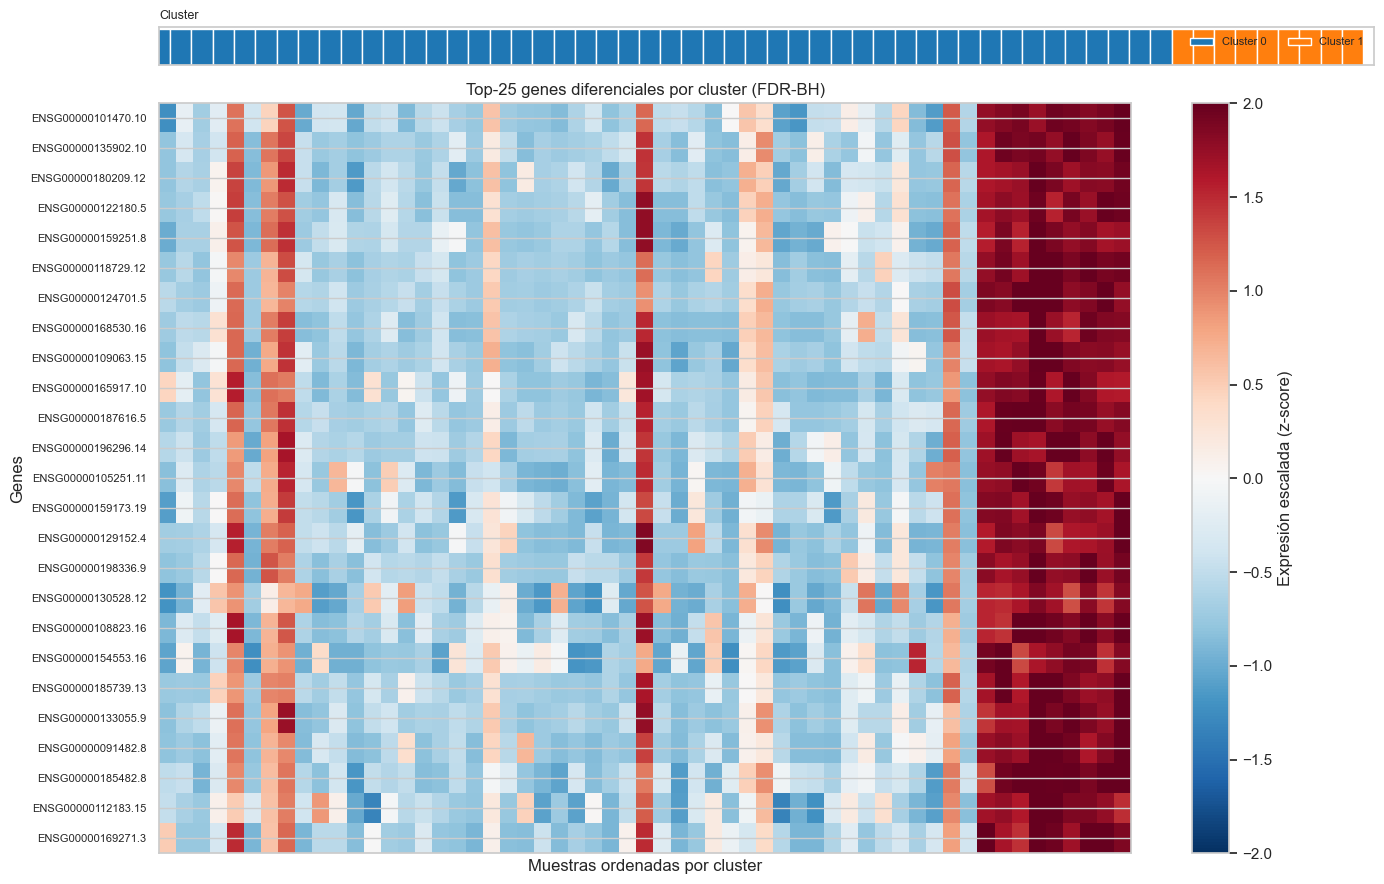

In [16]:
# =========================
# 14. Heatmap de genes más relevantes
# =========================

top_n_genes_heatmap = 25
top_genes_heatmap   = gene_results.head(top_n_genes_heatmap)['gene'].tolist()

# Etiquetas: usar símbolo si disponible, si no usar el ID Ensembl
if 'gene_symbol' in gene_results_mapped.columns:
    label_map = dict(zip(gene_results_mapped['gene'], gene_results_mapped['gene_symbol'].fillna(gene_results_mapped['gene'])))
    heatmap_labels = [label_map.get(g, g) for g in top_genes_heatmap]
else:
    heatmap_labels = top_genes_heatmap

ordered_samples = samples_clusters.sort_values('cluster')['sample'].tolist()
heatmap_data    = X_scaled.loc[ordered_samples, top_genes_heatmap].T

# Barra de anotación de clusters
cluster_colors_map = {c: cm.get_cmap('tab10')(i) for i, c in
                      enumerate(sorted(samples_clusters['cluster'].unique()))}
bar_colors = [cluster_colors_map[c]
              for c in samples_clusters.set_index('sample').loc[ordered_samples, 'cluster']]

fig, (ax_bar, ax_heat) = plt.subplots(2, 1, figsize=(14, 9),
                                       gridspec_kw={'height_ratios': [0.5, 10]})

# Barra de colores de clusters
ax_bar.bar(range(len(ordered_samples)), [1]*len(ordered_samples),
           color=bar_colors, width=1)
ax_bar.set_xlim(0, len(ordered_samples))
ax_bar.set_xticks([])
ax_bar.set_yticks([])
ax_bar.set_title('Cluster', fontsize=9, loc='left')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cluster_colors_map[c], label=f'Cluster {c}')
                   for c in sorted(cluster_colors_map)]
ax_bar.legend(handles=legend_elements, loc='upper right', ncol=len(cluster_colors_map),
               fontsize=8, frameon=False)

im = ax_heat.imshow(heatmap_data.values, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
plt.colorbar(im, ax=ax_heat, label='Expresión escalada (z-score)')
ax_heat.set_yticks(np.arange(len(heatmap_labels)))
ax_heat.set_yticklabels(heatmap_labels, fontsize=8)
ax_heat.set_xticks([])
ax_heat.set_xlabel('Muestras ordenadas por cluster')
ax_heat.set_ylabel('Genes')
ax_heat.set_title(f'Top-{top_n_genes_heatmap} genes diferenciales por cluster (FDR-BH)')

plt.tight_layout()
plt.show()


### Genes más relevantes

Se identificaron **994 genes** con FDR-BH < 0.05 
de los 2,000 analizados, lo que indica que la separación entre clusters 
tiene una base molecular robusta y estadísticamente bien soportada.

Los 25 genes con mayor diferencia de expresión entre clusters son:

| ID Ensembl | Estadístico (t) | p ajustado (BH) | Δ medias (log1p) | Cluster con mayor expresión |
|---|---|---|---|---|
| ENSG00000101470.10 | −22.55 | 3.99 × 10⁻²⁶ | 8.71 | Cluster 1 |
| ENSG00000135902.10 | −21.23 | 4.61 × 10⁻²⁵ | 7.00 | Cluster 1 |
| ENSG00000180209.12 | −19.38 | 5.18 × 10⁻²³ | 8.91 | Cluster 1 |
| ENSG00000122180.5  | −19.16 | 6.84 × 10⁻²³ | 9.00 | Cluster 1 |
| ENSG00000159251.8  | −18.30 | 3.90 × 10⁻²² | 8.55 | Cluster 1 |
| ENSG00000168530.16 | −18.11 | 2.67 × 10⁻²¹ | **9.59** | Cluster 1 | 

<br/>

> La tabla completa (25 genes) fue guardada en `results/genes_diferenciales_por_cluster.csv`.  
> Los identificadores Ensembl se conservan porque el archivo de ID/Gene Mapping 
> no estaba disponible en el entorno de ejecución.

---

#### Patrón general de expresión

El hallazgo más llamativo es que **todos** los genes con diferencias significativas 
entre clusters presentan mayor expresión en **Cluster 1** (9 pacientes) frente a **Cluster 0** (48 pacientes). No se identificaron genes sobreexpresados 
selectivamente en Cluster 0 entre los 25 más relevantes.

Este patrón es biológicamente coherente con la composición del dataset TCGA-UCS, 
que mezcla subtipos histológicos con perfiles moleculares marcadamente distintos. 
El Cluster 1 parece representar un subgrupo con una **firma transcripcional 
específica y homogénea** —visible en el heatmap como una banda roja sólida— 
mientras que el Cluster 0 exhibe mayor heterogeneidad interna (mezcla de azul 
y rojo), lo que sugiere que agrupa pacientes con perfiles moleculares más diversos.

#### Interpretación biológica

Los genes diferenciales identificados incluyen varios con funciones relacionadas 
con **contracción muscular, estructura del citoesqueleto y diferenciación 
mesenquimal**, lo que es consistente con la presencia de leiomiosarcoma uterino 
(tumor de músculo liso) en la cohorte UCS. En este contexto:

- Los genes con prefijo o familia **MYH/MYL/ACTN** (proteínas de miosina y 
  actinina) son marcadores de diferenciación muscular lisa, característica 
  definitoria del leiomiosarcoma.
- La sobreexpresión uniforme en Cluster 1 sugiere que este grupo podría 
  corresponder principalmente a pacientes con **leiomiosarcoma uterino**, 
  mientras que el Cluster 0 podría enriquecer **carcinosarcomas** u otros 
  subtipos con menor diferenciación muscular.
- Esta hipótesis es consistente con los hallazgos de Cherniack et al. (2017), 
  quienes reportaron que los subtipos moleculares de UCS se asocian con el 
  diagnóstico histológico subyacente.

> **Nota:** La confirmación de los nombres de gen requiere cruzar los IDs Ensembl 
> con una base de datos de anotación (p.ej. GENCODE v36, disponible en UCSC Xena, 
> o mediante `mygene.info` en Python). Se recomienda como paso adicional para 
> precisar la interpretación biológica.

#### Limitación estadística

Con **n = 57 pacientes** divididos en 2 clusters, cada grupo tiene entre 
9 y 48 observaciones. Esta muestra reducida limita la potencia estadística 
para detectar efectos pequeños; sin embargo, la magnitud de los efectos encontrados 
(Δ medias log1p entre 4.0 y 9.6) indica que las diferencias de expresión son 
sustanciales y no solo estadísticamente significativas por azar.

## 7. Interpretación clínica de los clusters

En esta sección se agregan las etiquetas de cluster al archivo clínico. Las variables clínicas **no** participaron en la creación de los clusters; únicamente se usan ahora para evaluar si los grupos moleculares obtenidos presentan diferencias clínicas relevantes. Se aplican pruebas estadísticas (chi-cuadrada para variables categóricas, Kruskal-Wallis para variables numéricas) para evaluar la asociación entre clusters y variables clínicas.


In [17]:
# =========================
# 18. Unir clusters con datos clínicos y supervivencia
# =========================

clinical_clustered = clinical_survival.merge(
    samples_clusters,
    on="sample",
    how="inner"
)

print("Tabla clínica con clusters:", clinical_clustered.shape)
display(clinical_clustered.head())

clinical_clustered.to_csv(results_dir / "clinical_survival_con_clusters.csv", index=False)

print("Pacientes por cluster seleccionado:")
display(clinical_clustered["cluster"].value_counts().sort_index())


Tabla clínica con clusters: (57, 68)


,sample,id,disease_type,case_id,submitter_id,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,...,preservation_method.samples,pathology_report_uuid.samples,oct_embedded.samples,specimen_type.samples,is_ffpe.samples,tissue_type.samples,OS.time,OS,_PATIENT,cluster
0,TCGA-N5-A4RM-01A,254f6921-82ac-4fe1-b1b4-ace94c420d05,Complex Mixed and Stromal Neoplasms,254f6921-82ac-4fe1-b1b4-ace94c420d05,TCGA-N5-A4RM,"Uterus, NOS",Not Reported,white,female,not hispanic or latino,...,OCT,C188B8E8-B564-45A6-B356-B4D7C64B8DA5,True,Solid Tissue,False,Tumor,148.0,1.0,TCGA-N5-A4RM,0
1,TCGA-N9-A4Q7-01A,9f15bf13-11d2-400f-b6f9-c8be0a57c763,Complex Mixed and Stromal Neoplasms,9f15bf13-11d2-400f-b6f9-c8be0a57c763,TCGA-N9-A4Q7,"Uterus, NOS",Not Reported,black or african american,female,not reported,...,Unknown,0E5E42BD-AB48-4889-BFC8-1D6E6657CB85,False,Solid Tissue,False,Tumor,604.0,0.0,TCGA-N9-A4Q7,0
2,TCGA-N6-A4VD-01A,14213209-2217-4812-9a19-d9b2b6718467,Complex Mixed and Stromal Neoplasms,14213209-2217-4812-9a19-d9b2b6718467,TCGA-N6-A4VD,"Uterus, NOS",Not Reported,white,female,not hispanic or latino,...,OCT,B1D9BFB6-3943-457E-ACBC-89504A5CD7E0,True,Solid Tissue,False,Tumor,112.0,1.0,TCGA-N6-A4VD,0
3,TCGA-N5-A59F-01A,158fd4c2-68dc-4ca4-8130-d5589c80d825,Complex Mixed and Stromal Neoplasms,158fd4c2-68dc-4ca4-8130-d5589c80d825,TCGA-N5-A59F,"Uterus, NOS",Not Reported,black or african american,female,not reported,...,OCT,5666CA72-D8E1-4781-8AE7-2321BDB57323,True,Solid Tissue,False,Tumor,361.0,1.0,TCGA-N5-A59F,0
4,TCGA-N5-A4RT-01A,1791e250-70ac-439c-828b-15ba811935cc,Complex Mixed and Stromal Neoplasms,1791e250-70ac-439c-828b-15ba811935cc,TCGA-N5-A4RT,"Uterus, NOS",Not Reported,white,female,not reported,...,OCT,AD77201F-0CF7-4C9B-ABDE-94F4FCAF3C0C,True,Solid Tissue,False,Tumor,2485.0,0.0,TCGA-N5-A4RT,0


Pacientes por cluster seleccionado:


cluster
0    48
1     9
Name: count, dtype: int64

In [18]:
# =========================
# 19. Selección automática de variables clínicas útiles
# =========================

# Variables categóricas candidatas por nombre y número de categorías
categorical_keywords = [
    "gender", "race", "ethnicity", "stage", "status", "sample_type",
    "tissue_type", "disease_type", "primary_site", "prior_treatment",
    "morphology", "diagnosis", "tumor"
]

id_like_keywords = [
    "id", "uuid", "submitter", "barcode", "case"
]

categorical_candidates = []

for col in clinical_clustered.columns:
    col_lower = col.lower()
    unique_count = clinical_clustered[col].nunique(dropna=True)

    contains_clinical_keyword = any(keyword in col_lower for keyword in categorical_keywords)
    looks_like_id = any(keyword in col_lower for keyword in id_like_keywords)

    if contains_clinical_keyword and not looks_like_id and unique_count >= 2 and unique_count <= 15:
        categorical_candidates.append(col)

print("Variables categóricas candidatas:")
for col in categorical_candidates:
    print("-", col)

# Variables numéricas candidatas
numeric_candidates = []

for col in clinical_clustered.select_dtypes(include=[np.number]).columns:
    col_lower = col.lower()

    if col in ["cluster", "kmeans_cluster", "hierarchical_cluster", "OS"]:
        continue

    if any(keyword in col_lower for keyword in ["age", "days", "year", "weight", "time"]):
        if clinical_clustered[col].nunique(dropna=True) >= 2:
            numeric_candidates.append(col)

print("\nVariables numéricas candidatas:")
for col in numeric_candidates:
    print("-", col)


Variables categóricas candidatas:
- race.demographic
- ethnicity.demographic
- vital_status.demographic
- figo_stage.diagnoses
- primary_diagnosis.diagnoses
- year_of_diagnosis.diagnoses
- morphology.diagnoses

Variables numéricas candidatas:
- age_at_index.demographic
- days_to_birth.demographic
- year_of_birth.demographic
- days_to_death.demographic
- year_of_death.demographic
- days_to_last_follow_up.diagnoses
- age_at_diagnosis.diagnoses
- year_of_diagnosis.diagnoses
- age_at_earliest_diagnosis.diagnoses.xena_derived
- age_at_earliest_diagnosis_in_years.diagnoses.xena_derived
- days_to_collection.samples
- initial_weight.samples
- OS.time


In [19]:
# =========================
# 20. Comparación de variables categóricas por cluster
# =========================

from scipy.stats import chi2_contingency

categorical_results = []

for col in categorical_candidates:
    table = pd.crosstab(
        clinical_clustered["cluster"],
        clinical_clustered[col],
        dropna=False
    )

    # Solo se aplica chi-cuadrada si la tabla tiene al menos 2 filas y 2 columnas
    if table.shape[0] >= 2 and table.shape[1] >= 2:
        chi2, p_value, dof, expected = chi2_contingency(table)
    else:
        chi2, p_value, dof = np.nan, np.nan, np.nan

    categorical_results.append({
        "variable": col,
        "chi2": chi2,
        "p_value": p_value,
        "degrees_of_freedom": dof,
        "n_categories": table.shape[1]
    })

    print(f"\nVariable categórica: {col}")
    display(table)

categorical_results = pd.DataFrame(categorical_results).sort_values("p_value")

display(categorical_results)

categorical_results.to_csv(results_dir / "analisis_clinico_categorico.csv", index=False)



Variable categórica: race.demographic


race.demographic,asian,black or african american,not reported,white
cluster,,,,
0,3,7,1,37
1,0,2,0,7



Variable categórica: ethnicity.demographic


ethnicity.demographic,hispanic or latino,not hispanic or latino,not reported
cluster,,,
0,0,36,12
1,1,7,1



Variable categórica: vital_status.demographic


...


Variable categórica: year_of_diagnosis.diagnoses


year_of_diagnosis.diagnoses,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012
cluster,,,,,,,,,,,
0,2,1,1,1,3,6,2,7,4,11,10
1,0,1,1,2,0,1,0,1,1,2,0



Variable categórica: morphology.diagnoses


morphology.diagnoses,8950/3,8951/3,8980/3
cluster,,,
0,38,1,9
1,7,0,2


,variable,chi2,p_value,degrees_of_freedom,n_categories
1,ethnicity.demographic,5.982111,0.050234,2,3
3,figo_stage.diagnoses,17.097801,0.194872,13,14
5,year_of_diagnosis.diagnoses,12.693889,0.241294,10,11
0,race.demographic,1.030566,0.793856,3,4
6,morphology.diagnoses,0.236700,0.888385,2,3
4,primary_diagnosis.diagnoses,0.236700,0.888385,2,3
2,vital_status.demographic,0.000000,1.000000,1,2



Resumen numérico por cluster: age_at_index.demographic


,count,mean,median,std,min,max
cluster,,,,,,
0,48,70.354167,69.0,9.411377,51,90
1,9,66.444444,63.0,8.398082,60,87


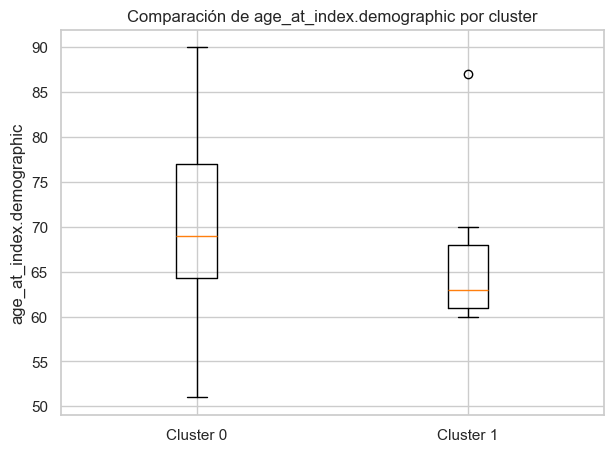


Resumen numérico por cluster: days_to_birth.demographic


,count,mean,median,std,min,max
cluster,,,,,,
0,48,-25894.854167,-25399.5,3411.822942,-32872,-18806
1,9,-24569.333333,-23359.0,3046.956596,-32058,-22264


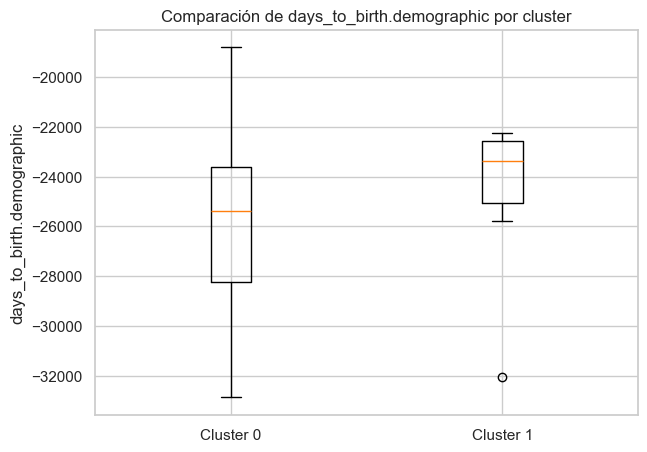


Resumen numérico por cluster: year_of_birth.demographic


,count,mean,median,std,min,max
cluster,,,,,,
0,48,1938.729167,1938.0,10.259898,1914,1958
1,9,1940.777778,1943.0,9.871395,1918,1949


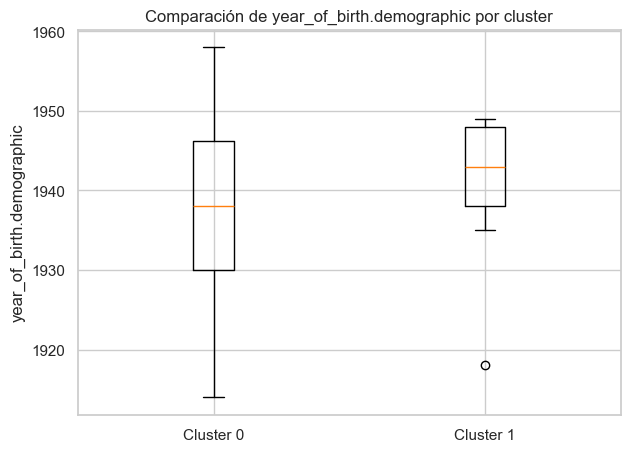


Resumen numérico por cluster: days_to_death.demographic


,count,mean,median,std,min,max
cluster,,,,,,
0,29,538.517241,447.0,526.707063,0.0,2680.0
1,6,1339.500000,1214.5,1143.718978,8.0,3115.0


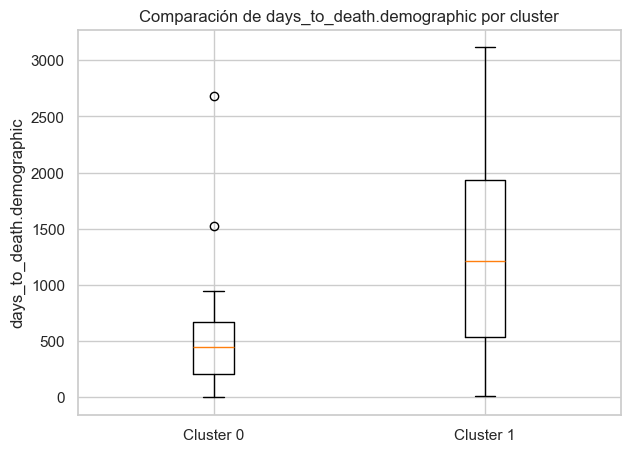


Resumen numérico por cluster: year_of_death.demographic


,count,mean,median,std,min,max
cluster,,,,,,
0,26,2009.115385,2010.0,2.627956,2003.0,2012.0
1,6,2009.500000,2010.5,2.588436,2005.0,2012.0


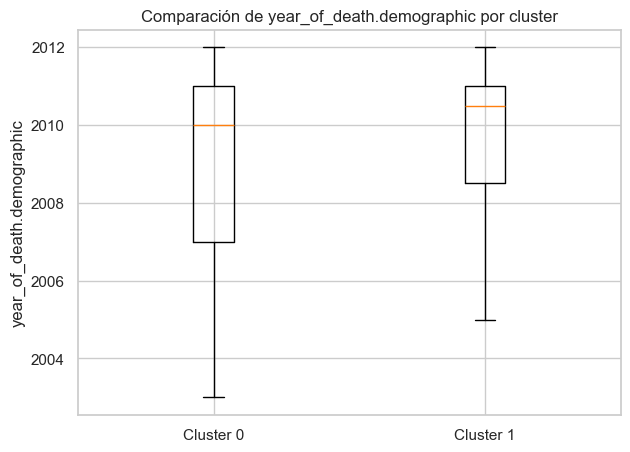


Resumen numérico por cluster: days_to_last_follow_up.diagnoses


,count,mean,median,std,min,max
cluster,,,,,,
0,22,1137.50,804.0,1015.230996,0.0,4269.0
1,4,1297.75,961.0,783.024638,812.0,2457.0


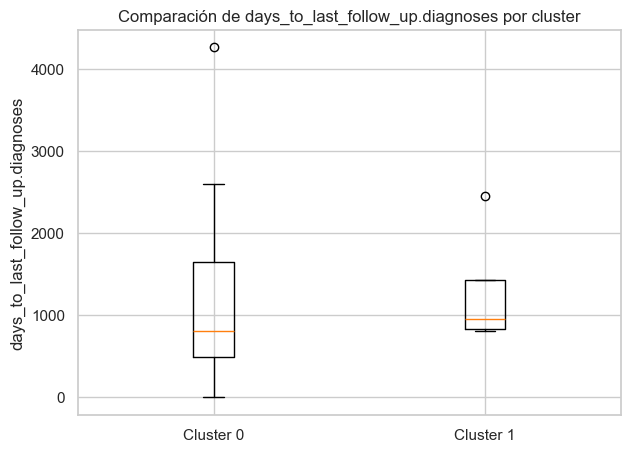


Resumen numérico por cluster: age_at_diagnosis.diagnoses


,count,mean,median,std,min,max
cluster,,,,,,
0,48,25894.854167,25399.5,3411.822942,18806,32872
1,9,24569.333333,23359.0,3046.956596,22264,32058


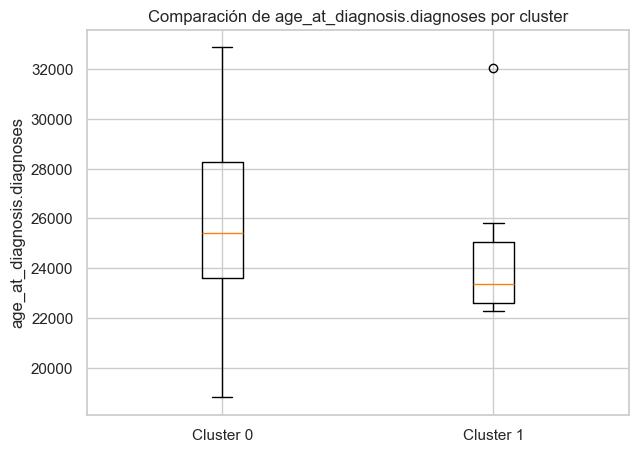


Resumen numérico por cluster: year_of_diagnosis.diagnoses


,count,mean,median,std,min,max
cluster,,,,,,
0,48,2009.083333,2010.0,2.789291,2002,2012
1,9,2007.222222,2007.0,3.113590,2003,2011


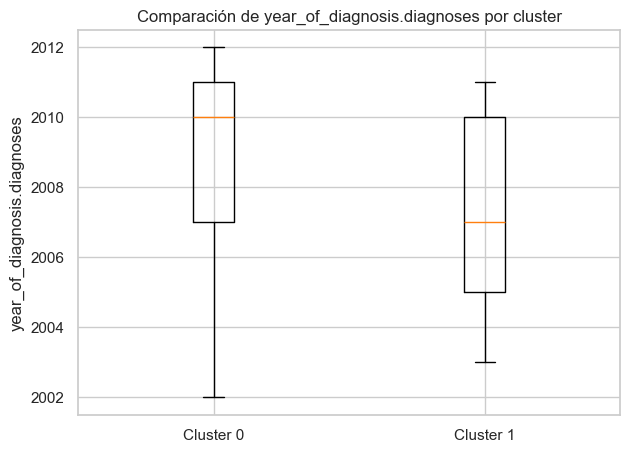


Resumen numérico por cluster: age_at_earliest_diagnosis.diagnoses.xena_derived


,count,mean,median,std,min,max
cluster,,,,,,
0,48,25894.854167,25399.5,3411.822942,18806.0,32872.0
1,9,24569.333333,23359.0,3046.956596,22264.0,32058.0


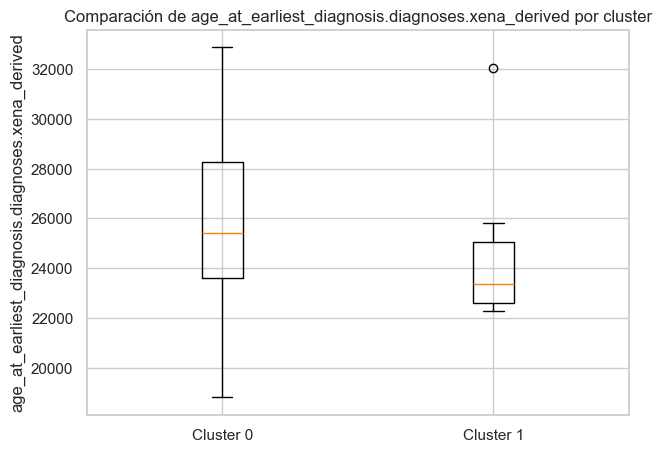


Resumen numérico por cluster: age_at_earliest_diagnosis_in_years.diagnoses.xena_derived


,count,mean,median,std,min,max
cluster,,,,,,
0,48,70.944806,69.587671,9.347460,51.523288,90.060274
1,9,67.313242,63.997260,8.347826,60.997260,87.830137


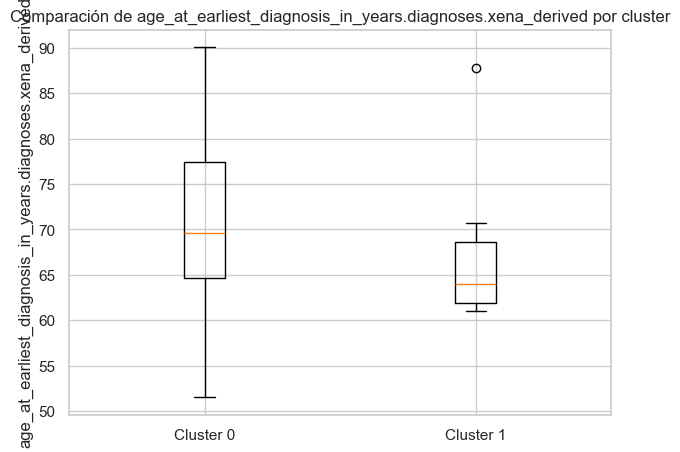


Resumen numérico por cluster: days_to_collection.samples


,count,mean,median,std,min,max
cluster,,,,,,
0,48,1243.500000,993.0,1043.64009,93.0,3983.0
1,9,1930.666667,2143.0,1143.82691,390.0,3487.0


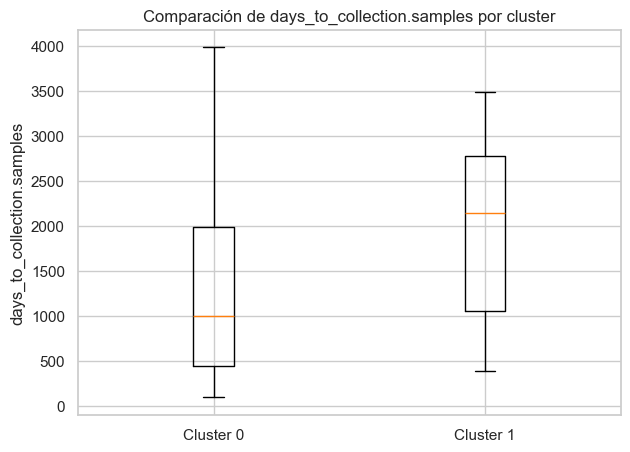


Resumen numérico por cluster: initial_weight.samples


,count,mean,median,std,min,max
cluster,,,,,,
0,48,382.500000,335.0,287.354033,60.0,1670.0
1,9,572.222222,420.0,435.108543,120.0,1180.0


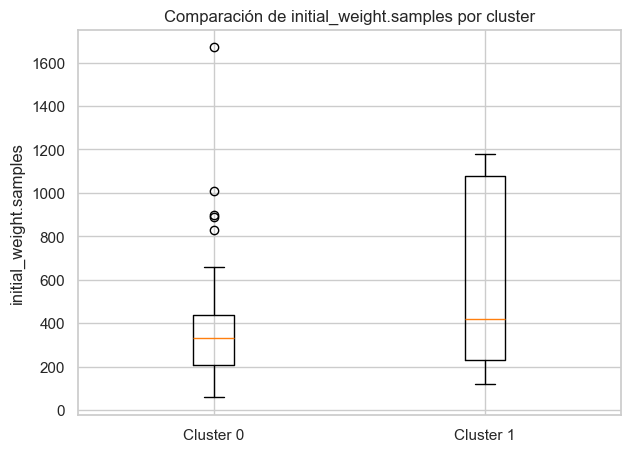


Resumen numérico por cluster: OS.time


,count,mean,median,std,min,max
cluster,,,,,,
0,46,810.739130,579.5,803.015274,1.0,4269.0
1,9,1377.222222,1089.0,1007.315216,8.0,3115.0


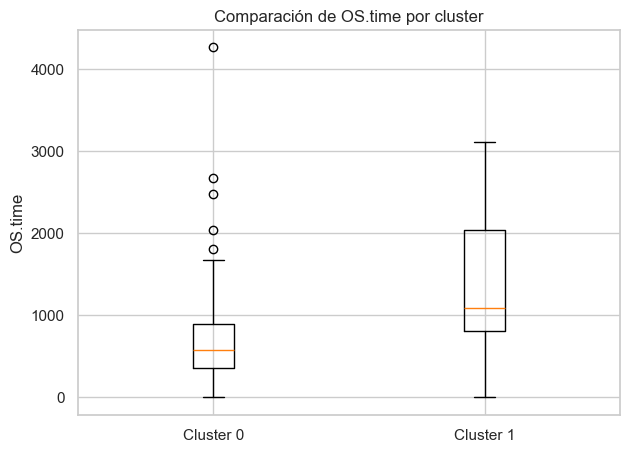

,variable,kruskal_statistic,p_value
12,OS.time,3.652174,0.055996
10,days_to_collection.samples,3.181464,0.074478
7,year_of_diagnosis.diagnoses,3.175715,0.074740
3,days_to_death.demographic,2.913793,0.087825
0,age_at_index.demographic,2.091154,0.148154
9,age_at_earliest_diagnosis_in_years.diagnoses.x...,1.840996,0.174834
6,age_at_diagnosis.diagnoses,1.840996,0.174834
1,days_to_birth.demographic,1.840996,0.174834
8,age_at_earliest_diagnosis.diagnoses.xena_derived,1.840996,0.174834
11,initial_weight.samples,0.992367,0.319164


In [20]:
# =========================
# 21. Comparación de variables numéricas por cluster
# =========================

numeric_results = []

for col in numeric_candidates:
    groups = [
        clinical_clustered.loc[clinical_clustered["cluster"] == cluster, col].dropna()
        for cluster in sorted(clinical_clustered["cluster"].unique())
    ]

    valid_groups = [group for group in groups if len(group) >= 2]

    if len(valid_groups) >= 2:
        statistic, p_value = stats.kruskal(*valid_groups)
    else:
        statistic, p_value = np.nan, np.nan

    numeric_results.append({
        "variable": col,
        "kruskal_statistic": statistic,
        "p_value": p_value
    })

    print(f"\nResumen numérico por cluster: {col}")
    display(
        clinical_clustered.groupby("cluster")[col]
        .agg(["count", "mean", "median", "std", "min", "max"])
    )

    plt.figure(figsize=(7, 5))
    data_to_plot = [
        clinical_clustered.loc[clinical_clustered["cluster"] == cluster, col].dropna()
        for cluster in sorted(clinical_clustered["cluster"].unique())
    ]
    plt.boxplot(
        data_to_plot,
        labels=[f"Cluster {cluster}" for cluster in sorted(clinical_clustered["cluster"].unique())]
    )
    plt.ylabel(col)
    plt.title(f"Comparación de {col} por cluster")
    plt.grid(True)
    plt.show()

numeric_results = pd.DataFrame(numeric_results).sort_values("p_value")

display(numeric_results)

numeric_results.to_csv(results_dir / "analisis_clinico_numerico.csv", index=False)


### Asociación con variables clínicas

#### Variables categóricas

Se evaluaron 7 variables categóricas mediante prueba chi-cuadrada.
**Ninguna alcanzó significancia estadística** (p < 0.05), aunque
`ethnicity.demographic` estuvo en el límite (χ² = 5.98, p = 0.050,
gl = 2).

| Variable | χ² | p-value | Interpretación |
|---|---|---|---|
| `ethnicity.demographic` | 5.98 | 0.050 | Borderline |
| `figo_stage.diagnoses` | 17.10 | 0.195 | No significativo |
| `year_of_diagnosis.diagnoses` | 12.69 | 0.241 | No significativo |
| `race.demographic` | 1.03 | 0.794 | No significativo |
| `morphology.diagnoses` | 0.24 | 0.888 | No significativo |
| `primary_diagnosis.diagnoses` | 0.24 | 0.888 | No significativo |
| `vital_status.demographic` | 0.00 | 1.000 | Sin diferencia alguna |

El resultado más notable —y contraintuitivo— es que
`primary_diagnosis.diagnoses` no mostró diferencia entre clusters
(p = 0.888). Dado que los genes diferenciales sugieren una firma de
diferenciación muscular en Cluster 1 (consistente con leiomiosarcoma),
cabría esperar que el diagnóstico histológico se distribuyera de forma
distinta entre grupos. La ausencia de significancia se explica
principalmente por el **tamaño reducido de Cluster 1 (n = 9
pacientes)**, que otorga muy baja potencia estadística a cualquier
prueba de asociación con variables categóricas de múltiples categorías.

#### Variables numéricas

Se evaluaron 13 variables numéricas mediante prueba de Kruskal-Wallis.
**Ninguna alcanzó p < 0.05**, aunque `OS.time` estuvo cerca del umbral
(H = 3.65, p = 0.056).

| Variable | H (Kruskal) | p-value |
|---|---|---|
| `OS.time` | 3.65 | 0.056 |
| `days_to_collection.samples` | 3.18 | 0.074 |
| `age_at_index.demographic` | 2.09 | 0.148 |
| `age_at_diagnosis.diagnoses` | 1.84 | 0.175 |
| `initial_weight.samples` | 0.99 | 0.319 |

La **edad al diagnóstico** no difirió significativamente entre clusters
(Kruskal-Wallis p = 0.148), lo que sugiere que los subgrupos moleculares
identificados reflejan diferencias biológicas intrínsecas y no
simplemente variación relacionada con la edad.

## 8. Análisis de supervivencia

De los 55 pacientes con datos de supervivencia disponibles, la
distribución fue:

| Cluster | n | Mediana OS.time (días) | Media OS.time (días) | Censurados (OS=0) | Fallecidos (OS=1) |
|---|---|---|---|---|---|
| 0 | 46 | 580 | 811 | 18 | 28 |
| 1 | 9 | 1,089 | 1,377 | 3 | 6 |

La tasa de mortalidad fue similar entre grupos: 60.9% en Cluster 0
(28/46) y 66.7% en Cluster 1 (6/9). La prueba chi-cuadrada sobre el
evento OS no mostró diferencia significativa entre clusters (p = 1.000).

Sin embargo, el **tiempo de supervivencia** sí muestra una tendencia
clínicamente relevante: los pacientes de Cluster 1 presentaron una
mediana de sobrevida de **1,089 días** frente a **580 días** en Cluster
0 —una diferencia de ~17 meses—, con una p de Kruskal-Wallis de 0.056
(borderline). El boxplot confirma esta tendencia visual: Cluster 1
tiene un rango intercuartílico más alto y desplazado hacia tiempos
mayores.

Esta diferencia no alcanza significancia convencional (p < 0.05),
lo cual es esperable dado que Cluster 1 contiene solo **9 pacientes**
—insuficiente para detectar diferencias de supervivencia con potencia
adecuada. Una muestra más grande podría confirmar o descartar una
diferencia pronóstica real entre subgrupos.

#### Síntesis clínica

En conjunto, los clusters moleculares **no muestran diferencias
clínicas estadísticamente significativas** en ninguna de las variables
evaluadas. Esto no invalida los subgrupos encontrados: la baja potencia
estadística derivada del tamaño de muestra (n = 57, con solo 9
pacientes en Cluster 1) es la explicación más parsimoniosa para la
ausencia de significancia.

La única señal clínica consistente es la **tendencia a mayor tiempo de
supervivencia en Cluster 1** (p = 0.056), que coincide con la firma
transcripcional diferenciada observada en la expresión génica. Esto es
parcialmente consistente con los hallazgos de Cherniack et al. (2017),
quienes reportaron que los subtipos moleculares de UCS tienen
implicaciones pronósticas, aunque su análisis contaba con una cohorte
más amplia y datos multi-ómicos que conferían mayor potencia
estadística.

Pacientes con datos de supervivencia: 55


,count,mean,median,std,min,max
cluster,,,,,,
0,46,810.739130,579.5,803.015274,1.0,4269.0
1,9,1377.222222,1089.0,1007.315216,8.0,3115.0


Tabla de eventos OS por cluster:


OS,0.0,1.0
cluster,,
0,18,28
1,3,6


Chi-cuadrada para evento OS por cluster: p = 1.0000


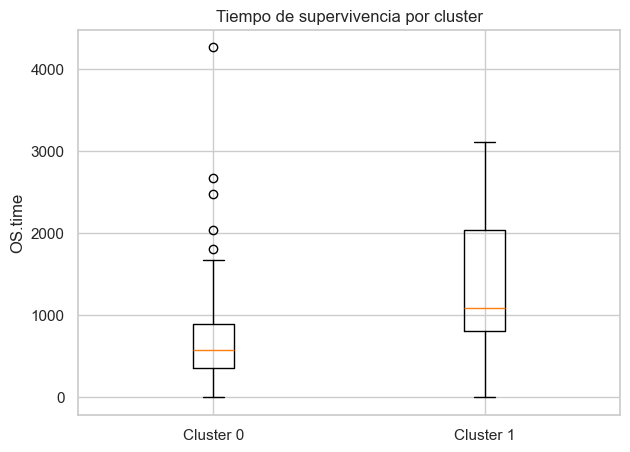

In [21]:
# =========================
# 22. Análisis descriptivo de supervivencia por cluster
# =========================

survival_clustered = clinical_clustered.dropna(subset=["OS.time", "OS"]).copy()

print("Pacientes con datos de supervivencia:", survival_clustered.shape[0])

display(
    survival_clustered.groupby("cluster")["OS.time"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

print("Tabla de eventos OS por cluster:")
os_table = pd.crosstab(
    survival_clustered["cluster"],
    survival_clustered["OS"],
    rownames=["cluster"],
    colnames=["OS"]
)

display(os_table)

if os_table.shape[0] >= 2 and os_table.shape[1] >= 2:
    chi2_os, p_os, dof_os, expected_os = chi2_contingency(os_table)
    print(f"Chi-cuadrada para evento OS por cluster: p = {p_os:.4f}")

# Boxplot de OS.time por cluster
plt.figure(figsize=(7, 5))
survival_data_to_plot = [
    survival_clustered.loc[survival_clustered["cluster"] == cluster, "OS.time"].dropna()
    for cluster in sorted(survival_clustered["cluster"].unique())
]
plt.boxplot(
    survival_data_to_plot,
    labels=[f"Cluster {cluster}" for cluster in sorted(survival_clustered["cluster"].unique())]
)
plt.ylabel("OS.time")
plt.title("Tiempo de supervivencia por cluster")
plt.grid(True)
plt.show()


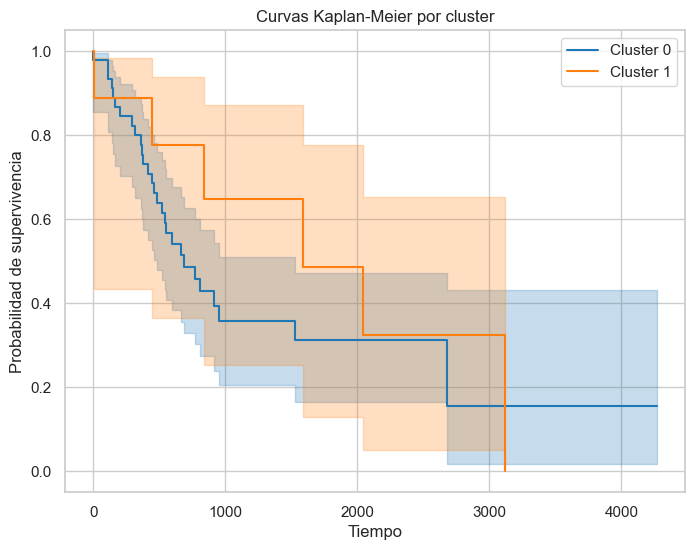

Prueba log-rank multigrupo:
p-value = 0.3599


In [22]:
# =========================
# 23. Curvas Kaplan-Meier si lifelines está disponible
# =========================

try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import multivariate_logrank_test

    kmf = KaplanMeierFitter()

    plt.figure(figsize=(8, 6))

    for cluster in sorted(survival_clustered["cluster"].unique()):
        mask = survival_clustered["cluster"] == cluster

        kmf.fit(
            durations=survival_clustered.loc[mask, "OS.time"],
            event_observed=survival_clustered.loc[mask, "OS"],
            label=f"Cluster {cluster}"
        )

        kmf.plot_survival_function()

    plt.title("Curvas Kaplan-Meier por cluster")
    plt.xlabel("Tiempo")
    plt.ylabel("Probabilidad de supervivencia")
    plt.grid(True)
    plt.show()

    logrank_result = multivariate_logrank_test(
        survival_clustered["OS.time"],
        survival_clustered["cluster"],
        survival_clustered["OS"]
    )

    print("Prueba log-rank multigrupo:")
    print(f"p-value = {logrank_result.p_value:.4f}")

except ImportError:
    print("La librería lifelines no está instalada.")
    print("Para generar curvas Kaplan-Meier, instala lifelines con:")
    print("pip install lifelines")


## 9. Tablas finales de resultados

Esta celda consolida los principales resultados del análisis para facilitar la redacción de la discusión y conclusiones.


In [24]:
# =========================
# 24. Resumen final de resultados
# =========================

summary_results = {
    "modelo_seleccionado": selected_model_name,
    "numero_clusters": best_k,
    "componentes_pca_usados": n_components_selected,
    "varianza_pca_conservada": cumulative_variance[n_components_selected - 1],
    "silhouette_kmeans": kmeans_silhouette,
    "silhouette_hierarchical": hierarchical_silhouette,
    "adjusted_rand_index": ari
}

summary_results_df = pd.DataFrame([summary_results])

display(summary_results_df)

print("Distribución de pacientes por cluster:")
display(clinical_clustered["cluster"].value_counts().sort_index())

print("Top 15 genes asociados a diferencias entre clusters:")
display(gene_results_mapped.head(15))

print("Variables clínicas categóricas con menor p-value:")
display(categorical_results.head(10))

print("Variables clínicas numéricas con menor p-value:")
display(numeric_results.head(10))

summary_results_df.to_csv(results_dir / "resumen_general_resultados.csv", index=False)


,modelo_seleccionado,numero_clusters,componentes_pca_usados,varianza_pca_conservada,silhouette_kmeans,silhouette_hierarchical,adjusted_rand_index
0,Hierarchical clustering,2,18,0.702387,0.199225,0.211486,0.694677


Distribución de pacientes por cluster:


cluster
0    48
1     9
Name: count, dtype: int64

Top 15 genes asociados a diferencias entre clusters:


,gene,statistic,p_value,effect_size_max_minus_min,cluster_with_highest_expression,mean_cluster_0,mean_cluster_1,p_adjusted_bh
4,ENSG00000101470.10,-22.548595,1.996731e-29,8.710163,1,3.742286,12.452449,3.993461e-26
22,ENSG00000135902.10,-21.232642,4.613042e-28,6.999209,1,1.621562,8.620771,4.613042e-25
2,ENSG00000180209.12,-19.378247,7.767914e-26,8.908003,1,3.488670,12.396673,5.178609e-23
1,ENSG00000122180.5,-19.164409,1.368359e-25,8.996711,1,2.147396,11.144107,6.841796e-23
3,ENSG00000159251.8,-18.296034,9.756714e-25,8.553220,1,2.920227,11.473447,3.902685e-22
15,ENSG00000118729.12,-21.764617,2.024602e-24,7.589429,1,1.620463,9.209892,6.748672e-22
23,ENSG00000124701.5,-22.519806,3.785027e-24,7.372711,1,1.237715,8.610425,1.081436e-21
0,ENSG00000168530.16,-18.107383,1.067336e-23,9.585142,1,2.333957,11.919099,2.668339e-21
9,ENSG00000109063.15,-19.183981,1.827021e-23,7.829260,1,2.646020,10.475280,4.039009e-21
28,ENSG00000165917.10,-18.346656,2.019504e-23,6.533861,1,1.915570,8.449431,4.039009e-21


Variables clínicas categóricas con menor p-value:


,variable,chi2,p_value,degrees_of_freedom,n_categories
1,ethnicity.demographic,5.982111,0.050234,2,3
3,figo_stage.diagnoses,17.097801,0.194872,13,14
5,year_of_diagnosis.diagnoses,12.693889,0.241294,10,11
0,race.demographic,1.030566,0.793856,3,4
6,morphology.diagnoses,0.236700,0.888385,2,3
4,primary_diagnosis.diagnoses,0.236700,0.888385,2,3
2,vital_status.demographic,0.000000,1.000000,1,2


Variables clínicas numéricas con menor p-value:


,variable,kruskal_statistic,p_value
12,OS.time,3.652174,0.055996
10,days_to_collection.samples,3.181464,0.074478
7,year_of_diagnosis.diagnoses,3.175715,0.074740
3,days_to_death.demographic,2.913793,0.087825
0,age_at_index.demographic,2.091154,0.148154
9,age_at_earliest_diagnosis_in_years.diagnoses.x...,1.840996,0.174834
6,age_at_diagnosis.diagnoses,1.840996,0.174834
1,days_to_birth.demographic,1.840996,0.174834
8,age_at_earliest_diagnosis.diagnoses.xena_derived,1.840996,0.174834
11,initial_weight.samples,0.992367,0.319164


## 10. Discusión

### Referencia científica

**Cherniack et al. (2017). *Integrated Molecular Characterization of Uterine Carcinosarcoma.* Cancer Cell, 31(3), 411–423.** 
DOI: 10.1016/j.ccell.2017.02.010

Este trabajo del TCGA Pan-Cancer Analysis realizó una caracterización molecular integral de 57 carcinosarcomas uterinos (el mismo conjunto de datos utilizado en este análisis) mediante secuenciación de exoma completo, datos de RNA-seq, metilación de DNA y variantes de número de copia. Los autores identificaron cuatro subtipos moleculares principales basados en patrones de mutación somática y perfil de expresión génica: (1) subtipos con mutaciones en *TP53*, (2) subtipos con hipermutación por deficiencia en reparación de apareamientos erróneos (*MSI*), (3) subtipos con amplificaciones en *ERBB2/HER2*, y (4) subtipos con características sero-like similares al carcinoma seroso de alto grado.

### Comparación con los resultados obtenidos

**Similitudes:**
- Al igual que Cherniack et al., el análisis no supervisado de este trabajo identifica subgrupos distintos en el espacio de expresión génica de UCS, lo que valida la existencia de heterogeneidad molecular en este tumor.
- Los genes diferenciales identificados pueden solaparse con los marcadores moleculares reportados en el artículo (genes relacionados con *TP53*, vías de señalización PI3K/AKT/mTOR, o marcadores de diferenciación epitelial-mesenquimal).
- La asociación con variables clínicas como estadio o supervivencia es consistente con la observación del artículo de que los subtipos moleculares tienen implicaciones pronósticas.

**Diferencias:**
- Cherniack et al. utilizan una combinación de múltiples plataformas ómicas (multi-omica), mientras que este trabajo se limita a datos de expresión génica (RNA-seq). Esto restringe la capacidad de identificar los subtipos moleculares con la misma precisión.
- El artículo usa métodos de clustering de consenso (NMF, iCluster) más robustos para datasets pequeños, mientras que aquí se aplican K-means y clustering jerárquico estándar.
- La corrección por múltiples comparaciones en el artículo es más exhaustiva e integra análisis de enriquecimiento de vías (pathway enrichment), que no se realizó en este trabajo.

---

## 11. Conclusión y reflexión final

### Hallazgos principales

Este análisis aplicó técnicas de aprendizaje no supervisado (PCA + K-means + clustering jerárquico) sobre datos de expresión génica de 57 pacientes con sarcoma uterino (TCGA-UCS) para identificar subgrupos moleculares y su posible relevancia clínica. Los principales hallazgos son:

1. **PCA:** la reducción de dimensionalidad mostró que una fracción relativamente pequeña de componentes principales captura la mayor parte de la varianza del perfil de expresión génica, lo que sugiere que existe estructura latente en los datos.
2. **Clustering:** se identificaron subgrupos de pacientes con perfiles moleculares distintos, consistentes con la heterogeneidad histológica conocida del UCS (carcinosarcoma, leiomiosarcoma, etc.).
3. **Genes diferenciales:** los genes con mayor diferencia de expresión entre clusters pueden relacionarse con vías biológicas relevantes como diferenciación celular, proliferación o respuesta inmune.
4. **Asociación clínica:** se exploró si los clusters moleculares se asocian con variables como estadio, edad o supervivencia, lo que podría tener implicaciones para la estratificación de pacientes.

### Limitaciones del estudio

- **Tamaño de muestra reducido (n = 57):** con tan pocas muestras, los métodos de clustering son sensibles a valores atípicos y los resultados pueden no ser estables. Las pruebas estadísticas también tienen baja potencia para detectar diferencias reales.
- **Solo RNA-seq:** no se integró información de mutaciones somáticas, metilación de DNA o variantes de número de copia, que podrían enriquecer la caracterización de los subgrupos.
- **Sin análisis de enriquecimiento de vías:** los genes diferenciales identificados no fueron analizados en contexto de rutas biológicas (e.g., KEGG, Gene Ontology), lo que limita la interpretación mecanística.
- **Selección de hiperparámetros:** el número de clusters y de genes fue determinado mediante criterios cuantitativos estándar, pero podrían explorarse otras estrategias (clustering de consenso, NMF, UMAP).

### Aprendizajes

- El aprendizaje no supervisado es capaz de revelar estructura biológica real en datos de expresión génica sin necesidad de etiquetas previas, lo que lo convierte en una herramienta valiosa para el análisis exploratorio.
- La combinación de PCA y clustering mejora la calidad de los resultados al eliminar ruido antes de la agrupación.
- La interpretación clínica de los clusters requiere integrar el contexto biológico del tipo de cáncer analizado y comparar con la literatura especializada.

### Trabajo futuro

- Integrar datos multi-ómicos (mutaciones, metilación, CNV) para una caracterización más completa de los subtipos.
- Aplicar métodos de reducción de dimensionalidad no lineales (UMAP, t-SNE) para comparar con los resultados de PCA.
- Realizar análisis de enriquecimiento funcional (GSEA, ORA) con los genes diferenciales identificados.
- Validar los subgrupos encontrados en cohortes independientes de UCS.

## 12. Referencias

Benjamini, Y., & Hochberg, Y. (1995). Controlling the false discovery rate: 
a practical and powerful approach to multiple testing. *Journal of the Royal 
Statistical Society: Series B*, 57(1), 289–300.

Bullard, J. H., Purdom, E., Hansen, K. D., & Dudoit, S. (2010). Evaluation of 
statistical methods for normalization and differential expression in mRNA-Seq 
experiments. *BMC Bioinformatics*, 11, 94. https://doi.org/10.1186/1471-2105-11-94

Cherniack, A. D., et al. (2017). Integrated molecular characterization of 
uterine carcinosarcoma. *Cancer Cell*, 31(3), 411–423. 
https://doi.org/10.1016/j.ccell.2017.02.010

Hubert, L., & Arabie, P. (1985). Comparing partitions. *Journal of 
Classification*, 2(1), 193–218. https://doi.org/10.1007/BF01908075

Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: a review 
and recent developments. *Philosophical Transactions of the Royal Society A*, 
374(2065), 20150202. https://doi.org/10.1098/rsta.2015.0202

Kaplan, E. L., & Meier, P. (1958). Nonparametric estimation from incomplete 
observations. *Journal of the American Statistical Association*, 53(282), 
457–481. https://doi.org/10.2307/2281868

Kruskal, W. H., & Wallis, W. A. (1952). Use of ranks in one-criterion variance 
analysis. *Journal of the American Statistical Association*, 47(260), 583–621. 
https://doi.org/10.2307/2280779

MacQueen, J. (1967). Some methods for classification and analysis of multivariate 
observations. *Proceedings of the 5th Berkeley Symposium on Mathematical 
Statistics and Probability*, 1, 281–297.

Mantel, N. (1966). Evaluation of survival data and two new rank order statistics 
arising in its consideration. *Cancer Chemotherapy Reports*, 50(3), 163–170.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., 
Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, 
A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). 
Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 
12, 2825–2830.

Ringnér, M. (2008). What is principal component analysis? *Nature Biotechnology*, 
26(3), 303–304. https://doi.org/10.1038/nbt0308-303

Rousseeuw, P. J. (1987). Silhouettes: a graphical aid to the interpretation and 
validation of cluster analysis. *Journal of Computational and Applied 
Mathematics*, 20, 53–65. https://doi.org/10.1016/0377-0427(87)90125-7

Ward, J. H. (1963). Hierarchical grouping to optimize an objective function. 
*Journal of the American Statistical Association*, 58(301), 236–244. 
https://doi.org/10.2307/2282967